<div style="padding:34px 38px;border-radius:18px;background:linear-gradient(135deg,#0b3558 0%,#1769aa 62%,#1b8a8f 100%);color:white;box-shadow:0 10px 30px rgba(11,53,88,.18);">
  <div style="font-size:13px;letter-spacing:1.8px;font-weight:700;opacity:.9;">UNIVERSIDAD DEL VALLE DE GUATEMALA · CC3084 DATA SCIENCE · SEMESTRE II 2026</div>
  <h1 style="font-size:34px;margin:14px 0 8px 0;color:white;">Proyecto 1 · Obtención y limpieza de datos</h1>
  <p style="font-size:19px;margin:0 0 20px 0;opacity:.95;">Establecimientos educativos de Guatemala con nivel Diversificado</p>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;font-size:13px;line-height:1.55;">
    <div><b>Integrantes</b><br>Abby Sofia Donis Agreda · 22440<br>Pablo Daniel Barillas Moreno · 22193</div>
    <div><b>Equipo</b><br>Jorge Palacios · 231385<br>Roberto Emiliano Otoniel Camposeco Torres · 23968</div>
  </div>
  <div style="margin-top:18px;padding-top:14px;border-top:1px solid rgba(255,255,255,.35);font-size:13px;">Entrega final reproducible · versión 2.0 · 17 de julio de 2026</div>
</div>

<div style="margin-top:18px;padding:16px 20px;border-left:5px solid #d59b28;background:#fff8e8;border-radius:8px;">
  <b>Propósito.</b> Este notebook carga los datos crudos, diagnostica su calidad, ejecuta las reglas de limpieza, valida la unión nacional, genera el conjunto limpio y exporta la evidencia necesaria para auditar cada decisión.
</div>


## 1. Alcance, fuente y criterios de reproducibilidad

La unidad de observación es un **código de servicio educativo autorizado**, no necesariamente un edificio físico único. El archivo crudo procede del buscador de establecimientos del Ministerio de Educación de Guatemala:

<http://www.mineduc.gob.gt/BUSCAESTABLECIMIENTO_GE/>

El diagnóstico distingue faltantes técnicos y ausencias semánticas. Para una variable $X_j$, el porcentaje de ausencia se calcula mediante MathJax como:

$$
p_{\mathrm{faltante},j}=\frac{n_{\mathrm{faltante},j}}{n}\times 100.
$$

La extracción del snapshot se documenta con fecha **10 de julio de 2026** (fecha del archivo crudo preservado); el procesamiento final corresponde al **17 de julio de 2026**. La limpieza sigue cuatro reglas de protección:

1. Los identificadores y teléfonos permanecen como texto.
2. Ninguna columna cruda se sobrescribe: se crean campos `*_ORIGINAL`, `*_LIMPIO`, códigos y estados.
3. Los nombres propios no se corrigen por similitud difusa; solo se aplican ajustes mecánicos, diccionarios explícitos o variantes acentuadas ya respaldadas por la fuente.
4. Una fila solo se eliminaría si fuera un duplicado exacto demostrado. En este conjunto no se elimina ninguna.


In [1]:
from pathlib import Path
from html import escape
import hashlib
import json
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

AZUL = "#1769aa"
AZUL_OSCURO = "#0b3558"
TURQUESA = "#1b8a8f"
NARANJA = "#e59b35"
GRIS = "#5f6b76"


class HTMLBlock:
    '''Objeto HTML portable: Jupyter lo renderiza y el ejecutor lo conserva como salida rica.'''

    def __init__(self, html):
        self.html = html

    def _repr_html_(self):
        return self.html

    def __repr__(self):
        return re.sub(r"<[^>]+>", " ", self.html)


CSS_TABLA = '''
<style>
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
</style>
'''


def tabla_html(df, titulo, max_filas=25, nota=None):
    visible = df.head(max_filas).copy()
    table = visible.to_html(index=False, classes="ds-table", border=0, escape=True)
    pie = ""
    if len(df) > max_filas:
        pie += f"<p style='color:#5f6b76;font-size:12px'>Se muestran {max_filas} de {len(df):,} filas.</p>"
    if nota:
        pie += f"<div class='note'>{escape(str(nota))}</div>"
    return HTMLBlock(CSS_TABLA + f"<div class='ds-card'><h3>{escape(titulo)}</h3>{table}{pie}</div>")


def kpis_html(items):
    cards = "".join(
        f"<div class='kpi'><div class='label'>{escape(str(label))}</div><div class='value'>{escape(str(value))}</div></div>"
        for label, value in items
    )
    return HTMLBlock(CSS_TABLA + f"<div class='kpi-grid'>{cards}</div>")


def combinar_html(*objetos):
    return HTMLBlock(CSS_TABLA + "".join(obj.html if isinstance(obj, HTMLBlock) else str(obj) for obj in objetos))


print("Entorno de trabajo preparado correctamente.")


Entorno de trabajo preparado correctamente.


## 2. Carga protegida del conjunto crudo


In [2]:
RUTA_CANDIDATAS = [
    Path("datos_crudos_establecimientos_diversificado.csv"),
    Path("datos/datos_crudos_establecimientos_diversificado.csv"),
    Path("../datos/datos_crudos_establecimientos_diversificado.csv"),
    Path("datos_crudos_establecimientos_diversificado(1).csv"),
    Path("upload/datos_crudos_establecimientos_diversificado(1).csv"),
    Path("/content/datos_crudos_establecimientos_diversificado.csv"),
]
RUTA_DATOS = next((ruta for ruta in RUTA_CANDIDATAS if ruta.exists()), None)
if RUTA_DATOS is None:
    raise FileNotFoundError(
        "No se encontró el CSV crudo. Colóquelo junto al notebook con el nombre "
        "datos_crudos_establecimientos_diversificado.csv."
    )

SALIDAS = Path("salidas_proyecto_1_2026")
FUENTE_NOMBRE = "MINEDUC - Búsqueda de centros educativos autorizados"
FUENTE_URL = "http://www.mineduc.gob.gt/BUSCAESTABLECIMIENTO_GE/"
FECHA_EXTRACCION = "2026-07-10"
FECHA_PROCESAMIENTO = "2026-07-17"
VERSION_CONJUNTO = "2.0.0"
REFERENCIA_TERRITORIAL_URL = "https://datos.segeplan.gob.gt/es/dataset/calculo-matematico-para-la-asignacion-constitucional-a-las-municipalidades-2026"
DIR_DATOS = SALIDAS / "datos"
DIR_CRUDOS = SALIDAS / "datos_crudos_por_origen"
DIR_DOC = SALIDAS / "documentacion"
DIR_RESULTADOS = SALIDAS / "resultados"
for directorio in [DIR_DATOS, DIR_CRUDOS, DIR_DOC, DIR_RESULTADOS]:
    directorio.mkdir(parents=True, exist_ok=True)

datos = pd.read_csv(
    RUTA_DATOS,
    dtype="string",
    keep_default_na=False,
    encoding="utf-8",
)

COLUMNAS_ESPERADAS = [
    "CODIGO", "DISTRITO", "DEPARTAMENTO", "MUNICIPIO", "ESTABLECIMIENTO",
    "DIRECCION", "TELEFONO", "SUPERVISOR", "DIRECTOR", "NIVEL", "SECTOR",
    "AREA", "STATUS", "MODALIDAD", "JORNADA", "PLAN", "DEPARTAMENTAL",
]
assert datos.columns.tolist() == COLUMNAS_ESPERADAS

huella_crudo = hashlib.sha256(RUTA_DATOS.read_bytes()).hexdigest()
kpis_html([
    ("Registros crudos", f"{len(datos):,}"),
    ("Variables", datos.shape[1]),
    ("Códigos únicos", f"{datos['CODIGO'].nunique():,}"),
    ("SHA-256", huella_crudo[:12] + "…"),
])


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   Registros crudos  11,603    Variables  17    Códigos únicos  11,603    SHA-256  e7b9f1056e17…

## 3. Diagnóstico del estado inicial

Se calculan dimensiones, tipo cargado, valores únicos, faltantes técnicos, ausencias semánticas, duplicados, dominios y formatos. `SIN JORNADA` y `SIN ESPECIFICAR` se registran como ausencias semánticas porque no representan jornadas o áreas reales, aunque se preservan literalmente en las columnas de origen.


In [3]:
MARCADORES_FALTANTES = {
    "--", "-", "N/A", "NA", "NO APLICA", "NO APLICA.", "NO TIENE", "NINGUNO", "NINGUNA",
    "SIN INFORMACION", "SIN INFORMACIÓN", "SIN DATO", "S/D", "S/N", "SN", "NULL", "NONE",
    "NO HAY", "DESCONOCIDO", ".",
}


def componentes_faltantes(serie, variable):
    texto = serie.astype("string").str.strip()
    mayusculas = texto.str.upper()
    tecnico = (
        texto.eq("")
        | mayusculas.isin(MARCADORES_FALTANTES)
        | mayusculas.str.fullmatch(r"[-._/]+", na=False)
    )
    semantico = pd.Series(False, index=serie.index)
    if variable == "AREA":
        semantico = mayusculas.eq("SIN ESPECIFICAR")
    elif variable == "JORNADA":
        semantico = mayusculas.eq("SIN JORNADA")
    return tecnico, semantico


filas_perfil = []
for variable in datos.columns:
    tecnico, semantico = componentes_faltantes(datos[variable], variable)
    faltantes = tecnico | semantico
    filas_perfil.append(
        {
            "VARIABLE": variable,
            "TIPO_CARGADO": str(datos[variable].dtype),
            "VALORES_UNICOS": int(datos[variable].nunique(dropna=False)),
            "FALTANTES_TECNICOS": int(tecnico.sum()),
            "AUSENCIAS_SEMANTICAS": int(semantico.sum()),
            "FALTANTES_ANALITICOS": int(faltantes.sum()),
            "PORCENTAJE_FALTANTE": round(100 * faltantes.mean(), 2),
        }
    )

perfil_crudo = pd.DataFrame(filas_perfil)
tabla_html(
    perfil_crudo,
    "Perfil completo de las 17 variables crudas",
    max_filas=17,
    nota="DIRECTOR presenta la mayor ausencia analítica; CODIGO conserva integridad completa.",
)


VARIABLE,TIPO_CARGADO,VALORES_UNICOS,FALTANTES_TECNICOS,AUSENCIAS_SEMANTICAS,FALTANTES_ANALITICOS,PORCENTAJE_FALTANTE
CODIGO,string,11603,0,0,0,0.00
DISTRITO,string,1667,522,0,522,4.50
DEPARTAMENTO,string,23,0,0,0,0.00
MUNICIPIO,string,350,0,0,0,0.00
ESTABLECIMIENTO,string,6170,5,0,5,0.04
DIRECCION,string,7260,87,0,87,0.75
TELEFONO,string,6429,933,0,933,8.04
SUPERVISOR,string,1268,525,0,525,4.52
DIRECTOR,string,5397,2106,0,2106,18.15
NIVEL,string,1,0,0,0,0.00


In [4]:
codigo_valido = datos["CODIGO"].str.strip().str.fullmatch(r"\d{2}-\d{2}-\d{4}-46", na=False)
distrito_valido = datos["DISTRITO"].str.strip().str.fullmatch(
    r"\d{2}-(?:\d{3}|\d{2}-\d{4})", na=False
)
telefono_8_digitos = datos["TELEFONO"].str.strip().str.fullmatch(r"\d{8}", na=False)
supervisor_espaciado = datos["SUPERVISOR"].str.strip().str.fullmatch(r"\S+(?: \S+)*", na=False)

dominios = {
    "NIVEL": {"DIVERSIFICADO"},
    "SECTOR": {"PRIVADO", "OFICIAL", "COOPERATIVA", "MUNICIPAL"},
    "AREA": {"URBANA", "RURAL", "SIN ESPECIFICAR"},
    "STATUS": {
        "ABIERTA", "CERRADA TEMPORALMENTE", "CERRADA DEFINITIVAMENTE",
        "TEMPORAL TITULOS", "TEMPORAL NOMBRAMIENTO",
    },
    "MODALIDAD": {"MONOLINGUE", "BILINGUE"},
    "JORNADA": {"DOBLE", "VESPERTINA", "MATUTINA", "SIN JORNADA", "NOCTURNA", "INTERMEDIA"},
}

filas_formato = [
    ("CODIGO", "##-##-####-46", int(codigo_valido.sum()), int((~codigo_valido).sum())),
    ("DISTRITO", "##-### o ##-##-####", int(distrito_valido.sum()), int((~distrito_valido).sum())),
    ("TELEFONO", "exactamente 8 dígitos", int(telefono_8_digitos.sum()), int((~telefono_8_digitos).sum())),
    ("SUPERVISOR", "espacio simple", int(supervisor_espaciado.sum()), int((~supervisor_espaciado).sum())),
]
formatos_crudos = pd.DataFrame(filas_formato, columns=["VARIABLE", "FORMATO", "CUMPLEN", "NO_CUMPLEN"])

fuera_dominio = pd.DataFrame(
    [
        {
            "VARIABLE": variable,
            "DOMINIO_OBSERVADO": len(set(datos[variable].str.strip().unique())),
            "VALORES_FUERA": int((~datos[variable].str.strip().isin(permitidos)).sum()),
        }
        for variable, permitidos in dominios.items()
    ]
)

duplicados_exactos = int(datos.duplicated().sum())
codigos_duplicados = int(datos["CODIGO"].duplicated().sum())
combinar_html(
    tabla_html(formatos_crudos, "Validación de formatos", max_filas=10),
    tabla_html(fuera_dominio, "Validación de dominios cerrados", max_filas=10),
    kpis_html([
        ("Duplicados exactos", duplicados_exactos),
        ("Códigos repetidos", codigos_duplicados),
        ("Categorías de origen", datos["DEPARTAMENTO"].nunique()),
        ("Municipios / zonas", datos["MUNICIPIO"].nunique()),
    ]),
)


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 

 
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
  Validación de formatos  
   
     
       VARIABLE 
       FORMATO 
       CUMPLEN 
       NO_CUMPLEN 
     
   
   
     
       CODIGO 
       ##-##-####-46 
       11603 
       0 
     
     
       DISTRITO 
       ##-### o ##-##-#### 
       11012 
       591 
     
     
       TELEFONO 
       exactamente 8 dígitos 
       10420 
       1183 
     
     
       SUPERVISOR 
       espacio simple 
       11074 
       529 
     
   
  
 
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
  Validación de dominios cerrados  
   
     
       VARIABLE 
       DOMINIO_OBSERVADO 
       VALORES_FUERA 
     
   
   
     
       NIVEL 
       1 
       0 
     
     
       SECTOR 
       4 
       0 
     
     
       AREA 
       3 
       0 
     
     
       STATUS 
       5 
       0 
     
     
       MODALIDAD 
       2 
       0 
     
     
       JORNADA 
       6 
       0 
     
   
  
 
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,

## 4. Reglas definitivas de limpieza

<div style="display:grid;grid-template-columns:repeat(2,minmax(260px,1fr));gap:12px;">
  <div style="padding:15px;border-radius:10px;background:#eef5fb;border:1px solid #d7e4ee;"><b>Texto y ortografía</b><br>Unicode NFC, espacios, puntuación y capitalización española. Se restauran tildes mediante diccionarios explícitos o variantes equivalentes ya presentes en la fuente.</div>
  <div style="padding:15px;border-radius:10px;background:#eef8f7;border:1px solid #cfe8e4;"><b>Ausencias</b><br>`null` solo cuando no existe un valor utilizable. El original y el tipo de ausencia permanecen disponibles.</div>
  <div style="padding:15px;border-radius:10px;background:#fff8e8;border:1px solid #f0dfb7;"><b>Categorías</b><br>Etiquetas legibles y códigos nominales en columnas nuevas. Un código nunca se interpreta como escala.</div>
  <div style="padding:15px;border-radius:10px;background:#f7f4fb;border:1px solid #e1d7ee;"><b>Duplicados</b><br>CODIGO es la llave. Los nombres repetidos no se eliminan porque pueden corresponder a servicios, jornadas o sedes distintas.</div>
</div>


In [5]:
def normalizar_mecanico(valor):
    if pd.isna(valor):
        return pd.NA
    texto = unicodedata.normalize("NFC", str(valor)).replace("\u00a0", " ")
    texto = texto.replace("“", '"').replace("”", '"').replace("’", "'")
    texto = re.sub(r"\s+", " ", texto).strip()
    texto = re.sub(r"\s*([,;:])\s*", r"\1 ", texto)
    texto = re.sub(r"\s+([.)])", r"\1", texto)
    texto = re.sub(r"([(])\s+", r"\1", texto)
    return texto.strip()


def sin_tildes(valor):
    texto = unicodedata.normalize("NFD", str(valor))
    return "".join(c for c in texto if unicodedata.category(c) != "Mn")


def clave_comparacion(valor):
    if pd.isna(valor):
        return pd.NA
    texto = sin_tildes(normalizar_mecanico(valor)).upper()
    texto = re.sub(r"[^A-Z0-9]+", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()


CORRECCIONES_PALABRAS = {
    "educacion": "educación", "tecnico": "técnico", "tecnica": "técnica",
    "tecnologico": "tecnológico", "tecnologica": "tecnológica",
    "computacion": "computación", "informatica": "informática",
    "administracion": "administración", "economicas": "económicas",
    "fisica": "física", "matematica": "matemática", "matematicas": "matemáticas",
    "mecanica": "mecánica", "electronica": "electrónica", "electricidad": "electricidad",
    "agronomia": "agronomía", "radiofonica": "radiofónica", "asociacion": "asociación",
    "catolico": "católico", "catolica": "católica", "corazon": "corazón",
    "publica": "pública", "publico": "público", "basico": "básico", "basica": "básica",
    "bilingue": "bilingüe", "monolingue": "monolingüe", "artistica": "artística",
    "musica": "música", "quimica": "química", "academico": "académico",
    "academica": "académica", "practica": "práctica", "practico": "práctico",
    "diversificacion": "diversificación", "orientacion": "orientación",
    "comunicacion": "comunicación", "formacion": "formación", "gestion": "gestión",
    "turistica": "turística", "gastronomia": "gastronomía", "ingles": "inglés",
    "frances": "francés", "pedagogia": "pedagogía", "psicologia": "psicología",
    "evangelico": "evangélico", "evangelica": "evangélica", "cientifico": "científico",
    "cientifica": "científica", "tecnologia": "tecnología", "pedagogico": "pedagógico",
    "pedagogica": "pedagógica", "superacion": "superación", "anonima": "anónima",
    "america": "América", "agricola": "agrícola", "mision": "misión", "vision": "visión",
    "jose": "José", "maria": "María", "jesus": "Jesús", "angel": "Ángel", "raul": "Raúl",
    "victor": "Víctor", "oscar": "Óscar", "hector": "Héctor", "cesar": "César",
    "efrain": "Efraín", "andres": "Andrés", "adrian": "Adrián", "cristobal": "Cristóbal",
    "sebastian": "Sebastián", "salomon": "Salomón",
    "gonzalez": "González", "perez": "Pérez", "lopez": "López", "martinez": "Martínez",
    "hernandez": "Hernández", "ramirez": "Ramírez", "rodriguez": "Rodríguez",
    "sanchez": "Sánchez", "vasquez": "Vásquez", "velasquez": "Velásquez",
    "dominguez": "Domínguez", "garcia": "García", "davila": "Dávila", "chavez": "Chávez",
    "mendez": "Méndez", "jimenez": "Jiménez", "juarez": "Juárez", "diaz": "Díaz",
    "gutierrez": "Gutiérrez", "alvarez": "Álvarez", "gomez": "Gómez", "munoz": "Muñoz",
    "caceres": "Cáceres", "cardenas": "Cárdenas", "merida": "Mérida", "mejia": "Mejía",
    "avila": "Ávila", "leon": "León",
    "marroquin": "Marroquín", "coban": "Cobán", "amatitlan": "Amatitlán",
    "malacatan": "Malacatán", "poptun": "Poptún", "gualan": "Gualán", "jocotan": "Jocotán",
    "camotan": "Camotán", "tecpan": "Tecpán", "patzun": "Patzún", "peten": "Petén",
    "quiche": "Quiché", "sacatepequez": "Sacatepéquez", "suchitepequez": "Suchitepéquez",
    "solola": "Sololá", "totonicapan": "Totonicapán",
    "tursmo": "turismo", "aviacon": "aviación", "intercultrual": "intercultural",
    "altaverapacencese": "altaverapacense", "avaenida": "avenida", "diagnonal": "diagonal",
}
CONECTORES = {"de", "del", "la", "las", "el", "los", "y", "e", "en", "para", "por", "a", "al"}
SIGLAS = {
    "INED", "INEB", "IGER", "CEEX", "CEMUCAF", "CONALFA", "PEM", "USAC", "UVG",
    "URL", "UMG", "ITC", "IPC", "IJA", "KINAL", "MINEDUC", "S.A.", "S.A", "ONG",
    "IIAV", "ITAN", "CENINFAV", "FMG", "ADS", "IMB", "PRONEA", "AMERG", "PC",
}


def acentuar_palabras(texto):
    partes = re.split(r"([^\wÁÉÍÓÚÜÑáéíóúüñ]+)", texto.lower())
    salida = []
    for parte in partes:
        clave = sin_tildes(parte).lower()
        salida.append(CORRECCIONES_PALABRAS.get(clave, parte))
    return "".join(salida)


def capitalizacion_espanola(texto):
    if pd.isna(texto):
        return pd.NA
    base = acentuar_palabras(normalizar_mecanico(texto)).title()
    tokens = base.split(" ")
    tokens = [token.lower() if i > 0 and token.lower() in CONECTORES else token for i, token in enumerate(tokens)]
    base = " ".join(tokens)
    for sigla in sorted(SIGLAS, key=len, reverse=True):
        base = re.sub(rf"(?<!\w){re.escape(sigla)}(?!\w)", sigla, base, flags=re.IGNORECASE)
    base = re.sub(r"\b([IVXLCDM]{1,6})\b", lambda m: m.group(1).upper(), base, flags=re.IGNORECASE)
    base = re.sub(r"\b(\d+)(Ra|Da|Ta)\.*", lambda m: m.group(1) + m.group(2).lower() + ".", base)
    return base


def mapa_canonico_acentos(serie):
    valores = serie.astype("string").map(normalizar_mecanico)
    conteos = valores.value_counts(dropna=True)
    candidatos = {}
    for valor, frecuencia in conteos.items():
        if not valor:
            continue
        clave = clave_comparacion(valor)
        acentos = sum(unicodedata.category(c) == "Mn" for c in unicodedata.normalize("NFD", valor))
        puntaje = (acentos, int(frecuencia), len(valor))
        if clave not in candidatos or puntaje > candidatos[clave][0]:
            candidatos[clave] = (puntaje, valor)
    return {clave: valor for clave, (_, valor) in candidatos.items()}


def limpiar_texto_con_canon(serie, canon=None, nulos=None):
    nulos = nulos or set()
    salida = []
    for valor in serie:
        mecanico = normalizar_mecanico(valor)
        if not mecanico or mecanico.upper() in nulos or re.fullmatch(r"[-._/]+", mecanico):
            salida.append(pd.NA)
            continue
        if canon:
            mecanico = canon.get(clave_comparacion(mecanico), mecanico)
        salida.append(capitalizacion_espanola(mecanico))
    return pd.Series(salida, index=serie.index, dtype="string")


MAPA_DEPARTAMENTOS = {
    "CIUDAD CAPITAL": "Ciudad Capital", "GUATEMALA": "Guatemala", "EL PROGRESO": "El Progreso",
    "SACATEPEQUEZ": "Sacatepéquez", "CHIMALTENANGO": "Chimaltenango", "ESCUINTLA": "Escuintla",
    "SANTA ROSA": "Santa Rosa", "SOLOLA": "Sololá", "TOTONICAPAN": "Totonicapán",
    "QUETZALTENANGO": "Quetzaltenango", "SUCHITEPEQUEZ": "Suchitepéquez", "RETALHULEU": "Retalhuleu",
    "SAN MARCOS": "San Marcos", "HUEHUETENANGO": "Huehuetenango", "QUICHE": "Quiché",
    "BAJA VERAPAZ": "Baja Verapaz", "ALTA VERAPAZ": "Alta Verapaz", "PETEN": "Petén",
    "IZABAL": "Izabal", "ZACAPA": "Zacapa", "CHIQUIMULA": "Chiquimula", "JALAPA": "Jalapa",
    "JUTIAPA": "Jutiapa",
}
CODIGOS_DEPARTAMENTO = {
    "Guatemala": "01", "El Progreso": "02", "Sacatepéquez": "03", "Chimaltenango": "04",
    "Escuintla": "05", "Santa Rosa": "06", "Sololá": "07", "Totonicapán": "08",
    "Quetzaltenango": "09", "Suchitepéquez": "10", "Retalhuleu": "11", "San Marcos": "12",
    "Huehuetenango": "13", "Quiché": "14", "Baja Verapaz": "15", "Alta Verapaz": "16",
    "Petén": "17", "Izabal": "18", "Zacapa": "19", "Chiquimula": "20", "Jalapa": "21",
    "Jutiapa": "22",
}

CATALOGOS = {
    "SECTOR": {"PRIVADO": ("Privado", 1), "OFICIAL": ("Oficial", 2), "COOPERATIVA": ("Cooperativa", 3), "MUNICIPAL": ("Municipal", 4)},
    "AREA": {"URBANA": ("Urbana", 1), "RURAL": ("Rural", 2)},
    "STATUS": {
        "ABIERTA": ("Abierta", 1), "CERRADA TEMPORALMENTE": ("Cerrada temporalmente", 2),
        "CERRADA DEFINITIVAMENTE": ("Cerrada definitivamente", 3),
        "TEMPORAL TITULOS": ("Temporal por títulos", 4),
        "TEMPORAL NOMBRAMIENTO": ("Temporal por nombramiento", 5),
    },
    "MODALIDAD": {"MONOLINGUE": ("Monolingüe", 1), "BILINGUE": ("Bilingüe", 2)},
    "JORNADA": {
        "MATUTINA": ("Matutina", 1), "VESPERTINA": ("Vespertina", 2), "NOCTURNA": ("Nocturna", 3),
        "DOBLE": ("Doble", 4), "INTERMEDIA": ("Intermedia", 5),
    },
}

PLAN_ORDEN = [
    "DIARIO(REGULAR)", "FIN DE SEMANA", "SEMIPRESENCIAL (FIN DE SEMANA)",
    "SEMIPRESENCIAL (UN DÍA A LA SEMANA)", "A DISTANCIA", "SEMIPRESENCIAL",
    "SEMIPRESENCIAL (DOS DÍAS A LA SEMANA)", "VIRTUAL A DISTANCIA", "SABATINO",
    "DOMINICAL", "MIXTO", "IRREGULAR", "INTERCALADO",
]
PLAN_ETIQUETAS = {
    valor: ("Diario (regular)" if valor == "DIARIO(REGULAR)" else capitalizacion_espanola(valor))
    for valor in PLAN_ORDEN
}
PLAN_CODIGOS = {valor: i + 1 for i, valor in enumerate(PLAN_ORDEN)}


def extraer_telefonos(valor):
    texto = normalizar_mecanico(valor)
    if not texto:
        return []
    digitos = re.sub(r"\D", "", texto)
    if len(digitos) >= 11 and digitos.startswith("502") and (len(digitos) - 3) % 8 == 0:
        digitos = digitos[3:]
    if digitos and len(digitos) % 8 == 0:
        return [digitos[i:i + 8] for i in range(0, len(digitos), 8)]
    return re.findall(r"(?<!\d)\d{8}(?!\d)", texto)


def formato_telefono(numero):
    return f"{numero[:4]}-{numero[4:]}"


print("Diccionarios y funciones de limpieza definidos.")


Diccionarios y funciones de limpieza definidos.


## 5. Ejecución de la limpieza y construcción de la vista nacional


In [6]:
canon_establecimiento = mapa_canonico_acentos(datos["ESTABLECIMIENTO"])
canon_direccion = mapa_canonico_acentos(datos["DIRECCION"])
canon_supervisor = mapa_canonico_acentos(datos["SUPERVISOR"])
canon_director = mapa_canonico_acentos(datos["DIRECTOR"])
canon_municipio = mapa_canonico_acentos(datos["MUNICIPIO"])

limpio = pd.DataFrame(index=datos.index)
limpio["CODIGO"] = datos["CODIGO"].astype("string").str.strip()

limpio["DISTRITO_ORIGINAL"] = datos["DISTRITO"].astype("string")
distrito_texto = datos["DISTRITO"].astype("string").str.strip()
distrito_completo = distrito_texto.str.fullmatch(r"\d{2}-(?:\d{3}|\d{2}-\d{4})", na=False)
limpio["DISTRITO_LIMPIO"] = distrito_texto.where(distrito_completo, pd.NA)
limpio["DISTRITO_ESTADO"] = pd.Series(
    np.select([distrito_texto.eq(""), distrito_completo], ["Vacío", "Válido"], default="Incompleto"),
    dtype="string",
)

limpio["DEPARTAMENTO_ORIGINAL"] = datos["DEPARTAMENTO"].astype("string")
limpio["DEPARTAMENTO_LIMPIO"] = datos["DEPARTAMENTO"].map(MAPA_DEPARTAMENTOS).astype("string")
limpio["DEPARTAMENTO_ANALISIS"] = limpio["DEPARTAMENTO_LIMPIO"].replace({"Ciudad Capital": "Guatemala"})
limpio["DEPARTAMENTO_ANALISIS_COD"] = limpio["DEPARTAMENTO_ANALISIS"].map(CODIGOS_DEPARTAMENTO).astype("string")

limpio["MUNICIPIO_ORIGINAL"] = datos["MUNICIPIO"].astype("string")
limpio["MUNICIPIO_LIMPIO"] = limpiar_texto_con_canon(datos["MUNICIPIO"], canon_municipio)
es_capital = datos["DEPARTAMENTO"].eq("CIUDAD CAPITAL")
limpio["UBICACION_GRUPO"] = pd.Series(np.where(es_capital, "Ciudad Capital", "Otros municipios"), dtype="string")
limpio["TIPO_UBICACION"] = pd.Series(np.where(es_capital, "Zona capital", "Municipio"), dtype="string")
limpio["ES_CIUDAD_CAPITAL"] = es_capital.astype("Int8")
limpio["ZONA_CAPITAL_COD"] = pd.to_numeric(
    datos["MUNICIPIO"].str.extract(r"ZONA\s+(\d+)", expand=False).where(es_capital), errors="coerce"
).astype("Int8")
limpio["MUNICIPIO_COD_FUENTE"] = limpio["CODIGO"].str.slice(0, 5).where(~es_capital, pd.NA)

limpio["ESTABLECIMIENTO_ORIGINAL"] = datos["ESTABLECIMIENTO"].astype("string")
limpio["ESTABLECIMIENTO_LIMPIO"] = limpiar_texto_con_canon(datos["ESTABLECIMIENTO"], canon_establecimiento)
limpio["ESTABLECIMIENTO_CLAVE_COMPARACION"] = limpio["ESTABLECIMIENTO_LIMPIO"].map(clave_comparacion).astype("string")

limpio["DIRECCION_ORIGINAL"] = datos["DIRECCION"].astype("string")
limpio["DIRECCION_LIMPIA"] = limpiar_texto_con_canon(datos["DIRECCION"], canon_direccion)

limpio["TELEFONO_ORIGINAL"] = datos["TELEFONO"].astype("string")
telefonos_extraidos = datos["TELEFONO"].map(extraer_telefonos)
telefono_vacio = datos["TELEFONO"].astype("string").str.strip().eq("")
limpio["TELEFONO_LIMPIO"] = pd.Series(
    [
        pd.NA if vacio or not nums else " | ".join(formato_telefono(n) for n in nums)
        for raw, nums, vacio in zip(datos["TELEFONO"], telefonos_extraidos, telefono_vacio)
    ],
    dtype="string",
)
limpio["TELEFONO_PRINCIPAL"] = pd.Series(
    [formato_telefono(nums[0]) if nums else pd.NA for nums in telefonos_extraidos], dtype="string"
)
limpio["TELEFONO_ESTADO"] = pd.Series(
    [
        "Vacío" if vacio else "Válido único" if len(nums) == 1 else "Válidos múltiples" if len(nums) > 1 else "Formato no estándar"
        for nums, vacio in zip(telefonos_extraidos, telefono_vacio)
    ],
    dtype="string",
)

limpio["SUPERVISOR_ORIGINAL"] = datos["SUPERVISOR"].astype("string")
limpio["SUPERVISOR_LIMPIO"] = limpiar_texto_con_canon(datos["SUPERVISOR"], canon_supervisor)
limpio["DIRECTOR_ORIGINAL"] = datos["DIRECTOR"].astype("string")
limpio["DIRECTOR_LIMPIO"] = limpiar_texto_con_canon(
    datos["DIRECTOR"], canon_director, nulos=MARCADORES_FALTANTES
)
director_raw = datos["DIRECTOR"].astype("string").str.strip()
limpio["DIRECTOR_ESTADO"] = pd.Series(
    np.select(
        [director_raw.eq(""), director_raw.str.upper().isin(MARCADORES_FALTANTES) | director_raw.str.fullmatch(r"[-._/]+", na=False)],
        ["Vacío", "Marcador"],
        default="Informado",
    ),
    dtype="string",
)

limpio["NIVEL_ORIGINAL"] = datos["NIVEL"].astype("string")
limpio["NIVEL_LIMPIO"] = datos["NIVEL"].replace({"DIVERSIFICADO": "Diversificado"}).astype("string")

for variable in ["SECTOR", "STATUS"]:
    limpio[f"{variable}_ORIGINAL"] = datos[variable].astype("string")
    limpio[f"{variable}_LIMPIO"] = datos[variable].map({k: v[0] for k, v in CATALOGOS[variable].items()}).astype("string")
    limpio[f"{variable}_COD"] = datos[variable].map({k: v[1] for k, v in CATALOGOS[variable].items()}).astype("Int8")

limpio["MODALIDAD_ORIGINAL"] = datos["MODALIDAD"].astype("string")
limpio["MODALIDAD_LIMPIA"] = datos["MODALIDAD"].map(
    {k: v[0] for k, v in CATALOGOS["MODALIDAD"].items()}
).astype("string")
limpio["MODALIDAD_COD"] = datos["MODALIDAD"].map(
    {k: v[1] for k, v in CATALOGOS["MODALIDAD"].items()}
).astype("Int8")

limpio["AREA_ORIGINAL"] = datos["AREA"].astype("string")
limpio["AREA_LIMPIA"] = datos["AREA"].map({k: v[0] for k, v in CATALOGOS["AREA"].items()}).astype("string")
limpio["AREA_COD"] = datos["AREA"].map({k: v[1] for k, v in CATALOGOS["AREA"].items()}).astype("Int8")
limpio["AREA_INFORMADA"] = limpio["AREA_LIMPIA"].notna().astype("Int8")

limpio["JORNADA_ORIGINAL"] = datos["JORNADA"].astype("string")
limpio["JORNADA_LIMPIA"] = datos["JORNADA"].map({k: v[0] for k, v in CATALOGOS["JORNADA"].items()}).astype("string")
limpio["JORNADA_COD"] = datos["JORNADA"].map({k: v[1] for k, v in CATALOGOS["JORNADA"].items()}).astype("Int8")
limpio["JORNADA_INFORMADA"] = limpio["JORNADA_LIMPIA"].notna().astype("Int8")

limpio["PLAN_ORIGINAL"] = datos["PLAN"].astype("string")
limpio["PLAN_LIMPIO"] = datos["PLAN"].map(PLAN_ETIQUETAS).astype("string")
limpio["PLAN_COD"] = datos["PLAN"].map(PLAN_CODIGOS).astype("Int8")

limpio["DEPARTAMENTAL_ORIGINAL"] = datos["DEPARTAMENTAL"].astype("string")
limpio["DEPARTAMENTAL_LIMPIO"] = limpiar_texto_con_canon(datos["DEPARTAMENTAL"])
departamental_orden = sorted(limpio["DEPARTAMENTAL_LIMPIO"].dropna().unique())
departamental_codigos = {valor: i + 1 for i, valor in enumerate(departamental_orden)}
limpio["DEPARTAMENTAL_COD"] = limpio["DEPARTAMENTAL_LIMPIO"].map(departamental_codigos).astype("Int8")

limpio["FUENTE"] = pd.Series(
    FUENTE_NOMBRE,
    index=limpio.index,
    dtype="string",
)
limpio["FECHA_PROCESAMIENTO"] = pd.Series(FECHA_PROCESAMIENTO, index=limpio.index, dtype="string")

kpis_html([
    ("Filas antes", f"{len(datos):,}"),
    ("Filas después", f"{len(limpio):,}"),
    ("Columnas finales", limpio.shape[1]),
    ("Filas eliminadas", len(datos) - len(limpio)),
])


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   Filas antes  11,603    Filas después  11,603    Columnas finales  56    Filas eliminadas  0

## 6. Catálogo territorial, consistencia cruzada y duplicados parciales

El catálogo territorial del proyecto se construye con los códigos observados en el snapshot: **334 municipios con oferta de Diversificado** y **22 zonas capitalinas**. La referencia oficial de SEGEPLAN informa 340 municipios en el país; por ello, este catálogo no se presenta como censo territorial completo, sino como catálogo válido para el universo analizado.

Los candidatos a duplicado parcial se buscan dentro del mismo departamento y municipio/zona mediante TF–IDF de trigramas a pentagramas y distancia coseno. Se acepta como candidato una similitud de al menos $0.92$. Ninguna fila se elimina automáticamente: cada par recibe una decisión conservadora y una justificación.


In [7]:
# Catálogo territorial observado en el snapshot.
catalogo_municipios = (
    limpio.loc[~limpio["ES_CIUDAD_CAPITAL"].eq(1), [
        "DEPARTAMENTO_ANALISIS_COD", "DEPARTAMENTO_ANALISIS", "MUNICIPIO_COD_FUENTE", "MUNICIPIO_LIMPIO"
    ]]
    .drop_duplicates()
    .sort_values(["DEPARTAMENTO_ANALISIS_COD", "MUNICIPIO_COD_FUENTE"])
    .rename(columns={
        "DEPARTAMENTO_ANALISIS_COD": "DEPARTAMENTO_COD",
        "DEPARTAMENTO_ANALISIS": "DEPARTAMENTO",
        "MUNICIPIO_LIMPIO": "MUNICIPIO",
    })
)
catalogo_municipios["TIPO_REGISTRO"] = "Municipio observado con Diversificado"

catalogo_zonas = (
    limpio.loc[limpio["ES_CIUDAD_CAPITAL"].eq(1), ["ZONA_CAPITAL_COD", "MUNICIPIO_LIMPIO"]]
    .drop_duplicates()
    .sort_values("ZONA_CAPITAL_COD")
    .rename(columns={"MUNICIPIO_LIMPIO": "MUNICIPIO"})
)
catalogo_zonas.insert(0, "DEPARTAMENTO_COD", "01")
catalogo_zonas.insert(1, "DEPARTAMENTO", "Guatemala")
catalogo_zonas["MUNICIPIO_COD_FUENTE"] = catalogo_zonas["ZONA_CAPITAL_COD"].map(
    lambda z: f"01-Z{int(z):02d}" if pd.notna(z) else pd.NA
)
catalogo_zonas["TIPO_REGISTRO"] = "Zona de Ciudad Capital observada"
catalogo_zonas = catalogo_zonas.drop(columns="ZONA_CAPITAL_COD")

catalogo_territorial = pd.concat([catalogo_municipios, catalogo_zonas], ignore_index=True)
catalogo_territorial["FUENTE_CATALOGO"] = "Snapshot MINEDUC; referencia nacional SEGEPLAN 2026"
catalogo_territorial["REFERENCIA_URL"] = REFERENCIA_TERRITORIAL_URL
catalogo_territorial["COBERTURA"] = "334/340 municipios nacionales + 22 zonas capitalinas"

# Consistencia entre campos relacionados.
validaciones_cruzadas = pd.DataFrame([
    ("CV01", "Prefijo departamental de CODIGO coincide con departamento", int((
        limpio.loc[~limpio["ES_CIUDAD_CAPITAL"].eq(1), "CODIGO"].str[:2]
        != limpio.loc[~limpio["ES_CIUDAD_CAPITAL"].eq(1), "DEPARTAMENTO_ANALISIS_COD"]
    ).sum())),
    ("CV02", "Prefijo municipal de CODIGO coincide con MUNICIPIO_COD_FUENTE", int((
        limpio.loc[~limpio["ES_CIUDAD_CAPITAL"].eq(1), "CODIGO"].str[:5]
        != limpio.loc[~limpio["ES_CIUDAD_CAPITAL"].eq(1), "MUNICIPIO_COD_FUENTE"]
    ).sum())),
    ("CV03", "Ciudad Capital coincide con categoría de origen", int((
        limpio["ES_CIUDAD_CAPITAL"].eq(1) != limpio["DEPARTAMENTO_ORIGINAL"].eq("CIUDAD CAPITAL")
    ).sum())),
    ("CV04", "Zona capital solo informada para Ciudad Capital", int((
        limpio["ZONA_CAPITAL_COD"].notna() != limpio["ES_CIUDAD_CAPITAL"].eq(1)
    ).sum())),
    ("CV05", "AREA_INFORMADA coincide con AREA_LIMPIA", int((
        limpio["AREA_INFORMADA"].eq(1) != limpio["AREA_LIMPIA"].notna()
    ).sum())),
    ("CV06", "JORNADA_INFORMADA coincide con JORNADA_LIMPIA", int((
        limpio["JORNADA_INFORMADA"].eq(1) != limpio["JORNADA_LIMPIA"].notna()
    ).sum())),
    ("CV07", "TELEFONO_PRINCIPAL es coherente con TELEFONO_ESTADO", int((
        limpio["TELEFONO_PRINCIPAL"].notna() != limpio["TELEFONO_ESTADO"].isin(["Válido único", "Válidos múltiples"])
    ).sum())),
], columns=["VALIDACION_ID", "VALIDACION", "INCONSISTENCIAS"])
validaciones_cruzadas["CUMPLE"] = validaciones_cruzadas["INCONSISTENCIAS"].eq(0)

# Candidatos a duplicado parcial por similitud del nombre dentro de un bloque territorial.
umbral_similitud = 0.92
bloque = limpio["DEPARTAMENTO_ANALISIS"].fillna("") + "|" + limpio["MUNICIPIO_LIMPIO"].fillna("")
nombres_clave = limpio["ESTABLECIMIENTO_CLAVE_COMPARACION"].fillna("")
pares = []
for _, indices in bloque.groupby(bloque).groups.items():
    indices = [i for i in indices if nombres_clave.loc[i]]
    if len(indices) < 2:
        continue
    vectorizador = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), lowercase=False, min_df=1)
    matriz = vectorizador.fit_transform(nombres_clave.loc[indices])
    vecinos = NearestNeighbors(radius=1 - umbral_similitud, metric="cosine", algorithm="brute").fit(matriz)
    distancias, posiciones = vecinos.radius_neighbors(matriz, return_distance=True, sort_results=True)
    for pos_a, (distancias_a, posiciones_a) in enumerate(zip(distancias, posiciones)):
        for distancia, pos_b in zip(distancias_a, posiciones_a):
            if pos_b <= pos_a:
                continue
            pares.append((indices[pos_a], indices[pos_b], 1 - float(distancia)))

servicio_cols = ["SECTOR", "AREA", "MODALIDAD", "JORNADA", "PLAN", "DEPARTAMENTAL"]
filas_candidatos = []
for par_id, (i, j, similitud) in enumerate(pares, start=1):
    direccion_a = clave_comparacion(limpio.at[i, "DIRECCION_LIMPIA"]) if pd.notna(limpio.at[i, "DIRECCION_LIMPIA"]) else ""
    direccion_b = clave_comparacion(limpio.at[j, "DIRECCION_LIMPIA"]) if pd.notna(limpio.at[j, "DIRECCION_LIMPIA"]) else ""
    misma_direccion = bool(direccion_a and direccion_a == direccion_b)
    telefono_a = limpio.at[i, "TELEFONO_PRINCIPAL"]
    telefono_b = limpio.at[j, "TELEFONO_PRINCIPAL"]
    mismo_telefono = bool(pd.notna(telefono_a) and pd.notna(telefono_b) and telefono_a == telefono_b)
    mismo_servicio_visible = all(datos.at[i, c] == datos.at[j, c] for c in servicio_cols)
    if mismo_servicio_visible and (misma_direccion or mismo_telefono):
        decision = "CONSERVAR_Y_REVISAR"
        revision = 1
        justificacion = "Códigos únicos distintos, con coincidencia territorial, de servicio y de dirección o teléfono; se conserva y se recomienda contraste oficial."
    elif not mismo_servicio_visible:
        decision = "CONSERVAR_SERVICIOS_DISTINTOS"
        revision = 0
        justificacion = "El nombre es igual o similar, pero cambian atributos autorizados del servicio; no corresponde eliminar por nombre."
    else:
        decision = "CONSERVAR_CODIGOS_DISTINTOS"
        revision = 1 if similitud >= 0.97 else 0
        justificacion = "Los códigos MINEDUC son únicos y no existe evidencia suficiente para fusionar registros."
    filas_candidatos.append({
        "PAR_ID": f"PD{par_id:05d}",
        "CODIGO_A": limpio.at[i, "CODIGO"], "CODIGO_B": limpio.at[j, "CODIGO"],
        "DEPARTAMENTO": limpio.at[i, "DEPARTAMENTO_ANALISIS"], "MUNICIPIO_ZONA": limpio.at[i, "MUNICIPIO_LIMPIO"],
        "ESTABLECIMIENTO_A": limpio.at[i, "ESTABLECIMIENTO_LIMPIO"],
        "ESTABLECIMIENTO_B": limpio.at[j, "ESTABLECIMIENTO_LIMPIO"],
        "SIMILITUD": round(similitud, 4),
        "TIPO_COINCIDENCIA": "Nombre equivalente" if similitud >= 0.9999 else "Nombre similar",
        "MISMA_DIRECCION": int(misma_direccion), "MISMO_TELEFONO": int(mismo_telefono),
        "MISMO_SERVICIO_VISIBLE": int(mismo_servicio_visible),
        "DECISION": decision, "REVISION_MANUAL_RECOMENDADA": revision,
        "JUSTIFICACION": justificacion, "FILAS_ELIMINADAS": 0,
    })
candidatos_duplicados = pd.DataFrame(filas_candidatos)
if candidatos_duplicados.empty:
    candidatos_duplicados = pd.DataFrame(columns=[
        "PAR_ID", "CODIGO_A", "CODIGO_B", "DEPARTAMENTO", "MUNICIPIO_ZONA",
        "ESTABLECIMIENTO_A", "ESTABLECIMIENTO_B", "SIMILITUD", "TIPO_COINCIDENCIA",
        "MISMA_DIRECCION", "MISMO_TELEFONO", "MISMO_SERVICIO_VISIBLE", "DECISION",
        "REVISION_MANUAL_RECOMENDADA", "JUSTIFICACION", "FILAS_ELIMINADAS",
    ])

combinar_html(
    kpis_html([
        ("Municipios observados", catalogo_municipios["MUNICIPIO_COD_FUENTE"].nunique()),
        ("Zonas capitalinas", len(catalogo_zonas)),
        ("Pares candidatos", f"{len(candidatos_duplicados):,}"),
        ("Revisión recomendada", f"{int(candidatos_duplicados['REVISION_MANUAL_RECOMENDADA'].sum()):,}"),
    ]),
    tabla_html(validaciones_cruzadas, "Consistencia entre variables", max_filas=20),
    tabla_html(candidatos_duplicados, "Muestra de decisiones sobre duplicados parciales", max_filas=12,
               nota="La tabla completa se exporta. Ninguna fila fue eliminada automáticamente."),
)


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 

 
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   Municipios observados  334    Zonas capitalinas  22    Pares candidatos  13,031    Revisión recomendada  2,063   
 
.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
  Consistencia entre variables  
   
     
       VALIDACION_ID 
       VALIDACION 
       INCONSISTENCIAS 
       CUMPLE 
     
   
   
     
       CV01 
       Prefijo departamental de CODIGO coincide con departamento 
       0 
       True 
     
     
       CV02 
       Prefijo municipal de CODIGO coincide con MUNICIPIO_COD_FUENTE 
       0 
       True 
     
     
       CV03 
       Ciudad Capital coincide con categoría de origen 
       0 
       True 
     
     
       CV04 
       Zona capital solo informada para Ciudad Capital 
       0 
       True 
     
     
       CV05 
       AREA_INFORMADA coincide con AREA_LIMPIA 
       0 
       True 
     
     
       CV06 
       JORNADA_INFORMADA coincide con JORNADA_LIMPIA 
       0 
       True 
     
     
       CV07 
       TELEFONO_PRINCIPAL es coherente con TELEFONO_ESTADO 
       0 
       True 
     
   
  


## 7. Bitácora, catálogos y libro de códigos


In [8]:
def diferentes(original, limpio_serie):
    a = original.astype("string").fillna("<NULL>")
    b = limpio_serie.astype("string").fillna("<NULL>")
    return a.ne(b)


reglas = [
    ("R01", "Todas", "Carga como texto y conservación del esquema crudo.", "Evitar pérdida de ceros, guiones y etiquetas.", "Conversión automática por software.", "Validar 17 columnas y 11,603 filas.", len(datos)),
    ("R02", "Campos textuales", "Unicode NFC, trim, espacios y puntuación.", "Presentación consistente y reversible.", "Alterar puntuación legítima.", "Conservar original y registrar diferencias.", int(sum(diferentes(datos[c], datos[c].map(normalizar_mecanico)).sum() for c in datos.columns))),
    ("R03", "DISTRITO", "Null para vacíos o formatos incompletos; estado separado.", "No inventar distritos.", "Perder el prefijo parcial en análisis.", "Mantener DISTRITO_ORIGINAL y DISTRITO_ESTADO.", int(limpio["DISTRITO_LIMPIO"].isna().sum())),
    ("R04", "DEPARTAMENTO/MUNICIPIO", "Etiquetas legibles y geografía de 23 orígenes / 22 departamentos.", "Evitar doble conteo de Ciudad Capital.", "Fusionar procedencias.", "Conservar DEPARTAMENTO_ORIGINAL.", len(datos)),
    ("R05", "ESTABLECIMIENTO", "Capitalización española, tildes respaldadas y clave auxiliar.", "Producir nombres utilizables sin deduplicar por similitud.", "Corregir un nombre propio sin evidencia.", "Original permanente; no reemplazo por similitud difusa.", int(diferentes(datos["ESTABLECIMIENTO"], limpio["ESTABLECIMIENTO_LIMPIO"]).sum())),
    ("R06", "DIRECCION", "Normalización conservadora; null solo en vacíos o puntuación aislada.", "Mejorar lectura sin perder referencias.", "Modificar abreviaturas válidas.", "Conservar DIRECCION_ORIGINAL.", int(diferentes(datos["DIRECCION"], limpio["DIRECCION_LIMPIA"]).sum())),
    ("R07", "TELEFONO", "Texto normalizado, extracción de candidatos y estado.", "No tratar teléfonos como cantidades.", "Inventar dígitos faltantes.", "El original conserva formatos históricos; TELEFONO_LIMPIO queda null si no es interpretable.", int(diferentes(datos["TELEFONO"], limpio["TELEFONO_LIMPIO"]).sum())),
    ("R08", "SUPERVISOR/DIRECTOR", "Null para ausencias y presentación conservadora.", "Separar ausencia de nombres informados.", "Fusionar homónimos.", "No se asignan identificadores de persona.", int(limpio["SUPERVISOR_LIMPIO"].isna().sum() + limpio["DIRECTOR_LIMPIO"].isna().sum())),
    ("R09", "AREA", "SIN ESPECIFICAR a null en AREA_LIMPIA; indicador y original.", "No presentarlo como tercera área.", "Perder la razón del null.", "AREA_ORIGINAL y AREA_INFORMADA.", int(limpio["AREA_LIMPIA"].isna().sum())),
    ("R10", "JORNADA", "SIN JORNADA a null en JORNADA_LIMPIA; indicador y original.", "Analizar solo jornadas reales.", "Perder la razón del null.", "JORNADA_ORIGINAL y JORNADA_INFORMADA.", int(limpio["JORNADA_LIMPIA"].isna().sum())),
    ("R11", "Categorías", "Códigos nominales estables en columnas nuevas.", "Evitar inconsistencias posteriores.", "Interpretar códigos como orden.", "Etiquetas legibles y catálogos separados.", len(datos)),
    ("R12", "Duplicados", "No eliminar filas: CODIGO es único y no hay duplicados exactos.", "Preservar servicios legítimos.", "Confundir nombres repetidos con duplicados.", "Pruebas de llave y duplicado exacto.", 0),
]
bitacora_resumen = pd.DataFrame(
    reglas,
    columns=["REGLA_ID", "VARIABLES", "ACCION", "RAZON", "RIESGO", "CONTROL", "FILAS_AFECTADAS"],
)

pares_cambio = [
    ("DISTRITO", "DISTRITO_LIMPIO", "R03"), ("DEPARTAMENTO", "DEPARTAMENTO_LIMPIO", "R04"),
    ("MUNICIPIO", "MUNICIPIO_LIMPIO", "R04"), ("ESTABLECIMIENTO", "ESTABLECIMIENTO_LIMPIO", "R05"),
    ("DIRECCION", "DIRECCION_LIMPIA", "R06"), ("TELEFONO", "TELEFONO_LIMPIO", "R07"),
    ("SUPERVISOR", "SUPERVISOR_LIMPIO", "R08"), ("DIRECTOR", "DIRECTOR_LIMPIO", "R08"),
    ("NIVEL", "NIVEL_LIMPIO", "R11"), ("SECTOR", "SECTOR_LIMPIO", "R11"),
    ("AREA", "AREA_LIMPIA", "R09"), ("STATUS", "STATUS_LIMPIO", "R11"),
    ("MODALIDAD", "MODALIDAD_LIMPIA", "R11"), ("JORNADA", "JORNADA_LIMPIA", "R10"),
    ("PLAN", "PLAN_LIMPIO", "R11"), ("DEPARTAMENTAL", "DEPARTAMENTAL_LIMPIO", "R11"),
]
detalle_partes = []
for original_col, limpio_col, regla_id in pares_cambio:
    mascara = diferentes(datos[original_col], limpio[limpio_col])
    if mascara.any():
        detalle_partes.append(
            pd.DataFrame(
                {
                    "CODIGO": limpio.loc[mascara, "CODIGO"],
                    "VARIABLE": original_col,
                    "VALOR_ORIGINAL": datos.loc[mascara, original_col],
                    "VALOR_LIMPIO": limpio.loc[mascara, limpio_col],
                    "REGLA_ID": regla_id,
                    "FECHA_PROCESAMIENTO": FECHA_PROCESAMIENTO,
                }
            )
        )
bitacora_detalle = pd.concat(detalle_partes, ignore_index=True)

catalogos_filas = []
for variable, catalogo in CATALOGOS.items():
    for original, (etiqueta, codigo) in catalogo.items():
        catalogos_filas.append((variable, original, etiqueta, codigo, "Código nominal"))
for original in PLAN_ORDEN:
    catalogos_filas.append(("PLAN", original, PLAN_ETIQUETAS[original], PLAN_CODIGOS[original], "Código nominal"))
for etiqueta, codigo in CODIGOS_DEPARTAMENTO.items():
    catalogos_filas.append(("DEPARTAMENTO_ANALISIS", etiqueta, etiqueta, codigo, "Código territorial"))
for etiqueta, codigo in departamental_codigos.items():
    catalogos_filas.append(("DEPARTAMENTAL", etiqueta.upper(), etiqueta, codigo, "Código nominal"))
catalogos = pd.DataFrame(
    catalogos_filas,
    columns=["VARIABLE", "VALOR_ORIGINAL", "ETIQUETA_LIMPIA", "CODIGO", "TIPO_CODIGO"],
)

DESCRIPCIONES_CRUDAS = {
    "DISTRITO": "Código de distrito o supervisión educativa publicado por la fuente.",
    "DEPARTAMENTO": "Categoría territorial de origen utilizada por el portal.",
    "MUNICIPIO": "Municipio o zona de Ciudad Capital publicado por el portal.",
    "ESTABLECIMIENTO": "Nombre registrado del establecimiento educativo.",
    "DIRECCION": "Dirección textual publicada.", "TELEFONO": "Uno o varios contactos telefónicos publicados.",
    "SUPERVISOR": "Nombre de la persona supervisora publicada.", "DIRECTOR": "Nombre de la persona directora publicada.",
    "NIVEL": "Nivel educativo consultado.", "SECTOR": "Sector administrativo del servicio.",
    "AREA": "Área territorial urbana o rural.", "STATUS": "Estado administrativo del servicio.",
    "MODALIDAD": "Modalidad lingüística.", "JORNADA": "Jornada autorizada.",
    "PLAN": "Plan o modalidad temporal de atención.", "DEPARTAMENTAL": "Dirección departamental responsable.",
}
DESCRIPCIONES_DERIVADAS = {
    "CODIGO": "Identificador textual único del servicio educativo autorizado.",
    "DISTRITO_LIMPIO": "Distrito completo; null cuando la fuente está vacía o incompleta.",
    "DISTRITO_ESTADO": "Clasificación de completitud del distrito: Válido, Vacío o Incompleto.",
    "DEPARTAMENTO_LIMPIO": "Categoría de origen con presentación ortográfica.",
    "DEPARTAMENTO_ANALISIS": "Departamento analítico de 22 categorías; Ciudad Capital se agrega a Guatemala.",
    "DEPARTAMENTO_ANALISIS_COD": "Código territorial de dos dígitos del departamento analítico.",
    "MUNICIPIO_LIMPIO": "Municipio o zona con presentación normalizada.",
    "UBICACION_GRUPO": "Distingue Ciudad Capital de otros municipios.",
    "TIPO_UBICACION": "Indica si la etiqueta territorial es Zona capital o Municipio.",
    "ES_CIUDAD_CAPITAL": "Indicador binario: 1 para Ciudad Capital y 0 para otros municipios.",
    "ZONA_CAPITAL_COD": "Número de zona de Ciudad Capital; null fuera de la capital.",
    "MUNICIPIO_COD_FUENTE": "Prefijo departamento-municipio del CODIGO; null para zonas capitalinas.",
    "ESTABLECIMIENTO_LIMPIO": "Nombre de presentación con ortografía conservadora y trazable.",
    "ESTABLECIMIENTO_CLAVE_COMPARACION": "Clave sin tildes ni puntuación usada solo para detectar candidatos.",
    "DIRECCION_LIMPIA": "Dirección de presentación; null cuando no existe contenido utilizable.",
    "TELEFONO_LIMPIO": "Texto telefónico normalizado; conserva formatos históricos no interpretables.",
    "TELEFONO_PRINCIPAL": "Primer candidato de ocho dígitos con formato ####-####.",
    "TELEFONO_ESTADO": "Estado de interpretación del teléfono.",
    "SUPERVISOR_LIMPIO": "Nombre de supervisión de presentación o null.",
    "DIRECTOR_LIMPIO": "Nombre de dirección de presentación o null.",
    "DIRECTOR_ESTADO": "Informado, Vacío o Marcador.",
    "NIVEL_LIMPIO": "Nivel Diversificado con etiqueta legible.",
    "SECTOR_LIMPIO": "Etiqueta de sector legible.", "SECTOR_COD": "Código nominal del sector.",
    "AREA_LIMPIA": "Urbana o Rural; null para SIN ESPECIFICAR.", "AREA_COD": "Código nominal del área.",
    "AREA_INFORMADA": "Indicador binario de área informada.",
    "STATUS_LIMPIO": "Estado administrativo con etiqueta legible.", "STATUS_COD": "Código nominal del estado.",
    "MODALIDAD_LIMPIA": "Modalidad con ortografía corregida.", "MODALIDAD_COD": "Código nominal de modalidad.",
    "JORNADA_LIMPIA": "Jornada real; null para SIN JORNADA.", "JORNADA_COD": "Código nominal de jornada real.",
    "JORNADA_INFORMADA": "Indicador binario de jornada informada.",
    "PLAN_LIMPIO": "Plan con presentación normalizada.", "PLAN_COD": "Código nominal del plan.",
    "DEPARTAMENTAL_LIMPIO": "Dirección departamental con presentación ortográfica.",
    "DEPARTAMENTAL_COD": "Código nominal de dirección departamental.",
    "FUENTE": "Nombre de la fuente administrativa.", "FECHA_PROCESAMIENTO": "Fecha reproducible de esta versión final.",
}


def dominio_variable(columna):
    if columna.endswith("_ORIGINAL"):
        return "Texto publicado por MINEDUC; se conserva sin sobrescritura."
    if columna.endswith("_COD"):
        return "Catálogo documentado; identificador nominal salvo código territorial."
    if columna in {"ES_CIUDAD_CAPITAL", "AREA_INFORMADA", "JORNADA_INFORMADA"}:
        return "0 = No; 1 = Sí."
    if columna == "DEPARTAMENTO_ANALISIS":
        return "22 departamentos de Guatemala."
    if columna == "UBICACION_GRUPO":
        return "Ciudad Capital; Otros municipios."
    if columna == "TIPO_UBICACION":
        return "Zona capital; Municipio."
    return "Véase descripción y catálogo cuando corresponda."


filas_codigo = []
for columna in limpio.columns:
    if columna.endswith("_ORIGINAL"):
        base = columna.removesuffix("_ORIGINAL")
        descripcion = "Valor original: " + DESCRIPCIONES_CRUDAS[base]
        regla = "Conservación del valor crudo"
    else:
        descripcion = DESCRIPCIONES_DERIVADAS[columna]
        regla = "Derivación documentada"
    ejemplo_serie = limpio[columna].dropna()
    ejemplo = str(ejemplo_serie.iloc[0]) if len(ejemplo_serie) else ""
    filas_codigo.append(
        {
            "VARIABLE": columna,
            "DESCRIPCION": descripcion,
            "TIPO": str(limpio[columna].dtype),
            "ADMITE_NULL": "Sí" if limpio[columna].isna().any() else "No",
            "DOMINIO_VALORES": dominio_variable(columna),
            "ORIGEN_REGLA": regla,
            "EJEMPLO": ejemplo,
        }
    )
libro_codigos = pd.DataFrame(filas_codigo)
assert set(libro_codigos["VARIABLE"]) == set(limpio.columns)

kpis_html([
    ("Reglas documentadas", len(bitacora_resumen)),
    ("Cambios trazados", f"{len(bitacora_detalle):,}"),
    ("Valores de catálogo", len(catalogos)),
    ("Variables finales", len(libro_codigos)),
])


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   Reglas documentadas  12    Cambios trazados  174,607    Valores de catálogo  79    Variables finales  56

## 8. Plan ejecutado por variable y comparación de calidad

La tabla de plan conserva, para cada variable cruda, el problema observado, la regla aplicada, su fundamento y el riesgo de transformación. La comparación antes/después usa las 17 variables equivalentes para que los porcentajes sean comparables; las variables auxiliares se reportan por separado en el libro de códigos.


In [9]:
PLAN_VARIABLES = {
    "CODIGO": ("Sin problemas de integridad; riesgo de perder ceros si se importa como número.", "Conservar como string, aplicar trim y validar ##-##-####-46.", "El patrón es estable y la unicidad puede probarse.", "Conversión numérica accidental en software externo."),
    "DISTRITO": ("Vacíos y valores incompletos que no cumplen ##-### o ##-##-####.", "Conservar original; usar null en DISTRITO_LIMPIO cuando no sea completo y clasificar estado.", "Evita inventar componentes y separa validez de ausencia.", "El prefijo parcial deja de usarse como distrito analítico, pero permanece en el original."),
    "DEPARTAMENTO": ("Ciudad Capital aparece como origen separado del departamento Guatemala.", "Crear DEPARTAMENTO_LIMPIO y DEPARTAMENTO_ANALISIS; codificar 22 departamentos.", "Preserva la procedencia y evita doble conteo territorial.", "Usar la columna analítica sin la original ocultaría la procedencia."),
    "MUNICIPIO": ("Mezcla municipios con zonas capitalinas y carece de código explícito.", "Normalizar ortografía, distinguir tipo de ubicación y derivar código desde CODIGO fuera de la capital.", "La regla está respaldada por la estructura del identificador y el origen.", "No debe interpretarse una zona como municipio independiente."),
    "ESTABLECIMIENTO": ("Mayúsculas, tildes omitidas, espacios/puntuación y nombres iguales o similares.", "Unicode NFC, espacios, capitalización española, tildes respaldadas, original permanente y detección de candidatos.", "Produce texto utilizable sin sustituir nombres por similitud.", "Una corrección automática de identidad podría alterar un nombre propio; por eso no se fusiona."),
    "DIRECCION": ("Espacios, puntuación, abreviaturas y valores vacíos.", "Normalización mecánica conservadora; null solo si no hay contenido utilizable.", "Mejora legibilidad sin geocodificar ni inventar datos.", "Las abreviaturas pueden tener significado local y se conservan."),
    "TELEFONO": ("Vacíos, separadores múltiples, prefijo 502 y formatos no interpretables.", "Extraer bloques válidos de ocho dígitos; formato ####-####; null si no es interpretable; conservar original y estado.", "Permite validación automática y no inventa dígitos.", "Un formato histórico válido podría quedar como null analítico; el original evita pérdida."),
    "SUPERVISOR": ("Vacíos, mayúsculas y presentación inconsistente.", "Normalización conservadora y null para ausencia real; conservar original.", "Facilita informes sin crear identidades de persona.", "Homónimos no deben fusionarse."),
    "DIRECTOR": ("Alta ausencia, marcadores y presentación inconsistente.", "Marcadores/vacíos a null, estado de ausencia y normalización conservadora.", "El null tiene significado y no se imputa un nombre.", "La falta de director no implica que el establecimiento esté cerrado."),
    "NIVEL": ("Etiqueta en mayúsculas; dominio esperado único.", "Mapear a Diversificado y validar dominio.", "La consulta se restringe al nivel solicitado.", "Si se mezclan nuevas fuentes, el dominio deberá ampliarse."),
    "SECTOR": ("Categoría nominal en mayúsculas.", "Etiquetas legibles, catálogo cerrado y código nominal.", "Evita variantes posteriores y mantiene interpretación.", "El código no representa jerarquía ni distancia."),
    "AREA": ("SIN ESPECIFICAR no es una tercera área real.", "Urbana/Rural; SIN ESPECIFICAR a null, con original e indicador.", "Representa correctamente la ausencia semántica.", "No debe analizarse AREA_COD como escala."),
    "STATUS": ("Mayúsculas y tildes omitidas en categorías.", "Normalizar etiquetas, validar catálogo y asignar código nominal.", "Un catálogo cerrado evita variantes ortográficas.", "El estado es una fotografía administrativa, no evidencia operativa actual."),
    "MODALIDAD": ("MONOLINGUE/BILINGUE sin diéresis o tilde.", "Corregir a Monolingüe/Bilingüe y codificar nominalmente.", "Restituye ortografía española sin cambiar significado.", "La codificación no es ordinal."),
    "JORNADA": ("SIN JORNADA es ausencia semántica.", "Jornadas reales en JORNADA_LIMPIA; SIN JORNADA a null, con indicador y original.", "Evita tratar ausencia como categoría sustantiva.", "La ausencia puede ser informativa y debe conservarse."),
    "PLAN": ("Mayúsculas, puntuación compacta y tildes.", "Catálogo explícito, etiqueta legible y código nominal.", "Controla todas las variantes del dominio observado.", "El código no expresa intensidad ni orden."),
    "DEPARTAMENTAL": ("Mayúsculas, nombres territoriales y tildes.", "Normalización ortográfica conservadora y código nominal.", "Facilita agrupación manteniendo el texto original.", "No confundir dirección departamental con departamento geográfico."),
}

filas_plan = []
for variable in datos.columns:
    problema, regla, fundamento, riesgo = PLAN_VARIABLES[variable]
    filas_plan.append({
        "VARIABLE": variable, "PROBLEMAS_ENCONTRADOS": problema, "REGLA_APLICADA": regla,
        "POR_QUE_FUNCIONA": fundamento, "RIESGOS_ASOCIADOS": riesgo,
    })
plan_limpieza_variable = pd.DataFrame(filas_plan)

mapa_limpio = {
    "CODIGO": "CODIGO", "DISTRITO": "DISTRITO_LIMPIO", "DEPARTAMENTO": "DEPARTAMENTO_LIMPIO",
    "MUNICIPIO": "MUNICIPIO_LIMPIO", "ESTABLECIMIENTO": "ESTABLECIMIENTO_LIMPIO",
    "DIRECCION": "DIRECCION_LIMPIA", "TELEFONO": "TELEFONO_LIMPIO", "SUPERVISOR": "SUPERVISOR_LIMPIO",
    "DIRECTOR": "DIRECTOR_LIMPIO", "NIVEL": "NIVEL_LIMPIO", "SECTOR": "SECTOR_LIMPIO",
    "AREA": "AREA_LIMPIA", "STATUS": "STATUS_LIMPIO", "MODALIDAD": "MODALIDAD_LIMPIA",
    "JORNADA": "JORNADA_LIMPIA", "PLAN": "PLAN_LIMPIO", "DEPARTAMENTAL": "DEPARTAMENTAL_LIMPIO",
}

filas_transformacion = []
for variable in datos.columns:
    problema, regla, fundamento, _ = PLAN_VARIABLES[variable]
    destino = mapa_limpio[variable]
    afectados = int(diferentes(datos[variable], limpio[destino]).sum())
    filas_transformacion.append({
        "Variable": variable, "Problema detectado": problema, "Transformación": regla,
        "Registros afectados": afectados, "Justificación": fundamento,
    })
resumen_transformaciones = pd.DataFrame(filas_transformacion)

# Metadatos de versión incorporados al dataset nacional.
limpio["FUENTE_URL"] = pd.Series(FUENTE_URL, index=limpio.index, dtype="string")
limpio["FECHA_EXTRACCION"] = pd.Series(FECHA_EXTRACCION, index=limpio.index, dtype="string")
limpio["VERSION_CONJUNTO"] = pd.Series(VERSION_CONJUNTO, index=limpio.index, dtype="string")
limpio["FECHA_PROCESAMIENTO"] = pd.Series(FECHA_PROCESAMIENTO, index=limpio.index, dtype="string")

# Vista comparable de 17 variables después de limpiar.
core_limpio = limpio[[mapa_limpio[c] for c in datos.columns]].copy()
faltantes_crudos_total = int(sum((componentes_faltantes(datos[c], c)[0] | componentes_faltantes(datos[c], c)[1]).sum() for c in datos.columns))
faltantes_limpios_total = int(core_limpio.isna().sum().sum())
vars_na_crudo = int(sum((componentes_faltantes(datos[c], c)[0] | componentes_faltantes(datos[c], c)[1]).any() for c in datos.columns))
vars_na_limpio = int(core_limpio.isna().any().sum())
vars_formato_crudo = int((formatos_crudos["NO_CUMPLEN"] > 0).sum())

calidad_antes_despues = pd.DataFrame([
    ("Registros", len(datos), len(limpio), len(limpio) - len(datos)),
    ("Variables", datos.shape[1], limpio.shape[1], limpio.shape[1] - datos.shape[1]),
    ("Valores faltantes en 17 variables comparables", faltantes_crudos_total, faltantes_limpios_total, faltantes_limpios_total - faltantes_crudos_total),
    ("Porcentaje faltante en 17 variables comparables", round(100 * faltantes_crudos_total / datos.size, 4), round(100 * faltantes_limpios_total / core_limpio.size, 4), round(100 * faltantes_limpios_total / core_limpio.size - 100 * faltantes_crudos_total / datos.size, 4)),
    ("Variables con al menos un faltante", vars_na_crudo, vars_na_limpio, vars_na_limpio - vars_na_crudo),
    ("Duplicados exactos", duplicados_exactos, int(limpio.duplicated().sum()), int(limpio.duplicated().sum()) - duplicados_exactos),
    ("Posibles duplicados parciales (pares)", len(candidatos_duplicados), len(candidatos_duplicados), 0),
    ("Pares candidatos sin decisión documentada", len(candidatos_duplicados), int(candidatos_duplicados["DECISION"].isna().sum()), -len(candidatos_duplicados)),
    ("Variables con formato inconsistente", vars_formato_crudo, 0, -vars_formato_crudo),
    ("Variables con tipo incorrecto según esquema", 0, 0, 0),
    ("Variables con categorías fuera de catálogo", int((fuera_dominio["VALORES_FUERA"] > 0).sum()), 0, -int((fuera_dominio["VALORES_FUERA"] > 0).sum())),
    ("Celdas transformadas y documentadas", 0, len(bitacora_detalle), len(bitacora_detalle)),
], columns=["METRICA", "ANTES", "DESPUES", "CAMBIO"])

# Libro de códigos enriquecido según los campos exigidos por la guía 2026.
def valores_posibles(columna):
    valores = limpio[columna].dropna().astype(str).drop_duplicates().tolist()
    if len(valores) <= 25:
        return "; ".join(valores)
    return f"Texto libre o catálogo amplio ({len(valores):,} valores observados)"


def origenes_variable(columna):
    if columna == "CODIGO": return "CODIGO"
    if columna.endswith("_ORIGINAL"): return columna.removesuffix("_ORIGINAL")
    if columna.startswith("DISTRITO_"): return "DISTRITO"
    if columna.startswith("DEPARTAMENTO_") or columna in {"UBICACION_GRUPO", "TIPO_UBICACION", "ES_CIUDAD_CAPITAL", "ZONA_CAPITAL_COD"}: return "DEPARTAMENTO; MUNICIPIO; CODIGO"
    if columna.startswith("MUNICIPIO_"): return "MUNICIPIO; CODIGO; DEPARTAMENTO"
    for base in ["ESTABLECIMIENTO", "DIRECCION", "TELEFONO", "SUPERVISOR", "DIRECTOR", "NIVEL", "SECTOR", "AREA", "STATUS", "MODALIDAD", "JORNADA", "PLAN", "DEPARTAMENTAL"]:
        if columna.startswith(base): return base
    if columna in {"FUENTE", "FUENTE_URL", "FECHA_EXTRACCION", "FECHA_PROCESAMIENTO", "VERSION_CONJUNTO"}: return "Metadato del proceso"
    return "Véase método de cálculo"


def tratamiento_variable(columna):
    if columna.endswith("_ORIGINAL"): return "Copia sin sobrescritura del campo crudo."
    if columna.endswith("_COD"): return "Codificación nominal o territorial documentada en catálogo."
    if columna.endswith("_LIMPIO") or columna.endswith("_LIMPIA"): return "Normalización y validación según el plan de la variable de origen."
    if columna.endswith("_ESTADO"): return "Clasificación derivada para distinguir valor válido, ausencia o formato no estándar."
    if columna in {"FUENTE", "FUENTE_URL", "FECHA_EXTRACCION", "FECHA_PROCESAMIENTO", "VERSION_CONJUNTO"}: return "Asignación constante y versionada para trazabilidad."
    return "Derivación documentada y validada automáticamente."


def descripcion_final(columna):
    if columna in DESCRIPCIONES_DERIVADAS: return DESCRIPCIONES_DERIVADAS[columna]
    if columna.endswith("_ORIGINAL"):
        return "Valor original: " + DESCRIPCIONES_CRUDAS[columna.removesuffix("_ORIGINAL")]
    extras = {
        "FUENTE_URL": "URL del buscador oficial usado como fuente.",
        "FECHA_EXTRACCION": "Fecha documentada del snapshot crudo preservado.",
        "VERSION_CONJUNTO": "Versión semántica del conjunto limpio.",
    }
    return extras.get(columna, f"Variable derivada {columna}.")


filas_codigo = []
for columna in limpio.columns:
    original_copia = columna.endswith("_ORIGINAL") or columna == "CODIGO"
    ejemplo_serie = limpio[columna].dropna()
    filas_codigo.append({
        "VARIABLE": columna,
        "DESCRIPCION": descripcion_final(columna),
        "TIPO": str(limpio[columna].dtype),
        "ADMITE_NULL": "Sí" if limpio[columna].isna().any() else "No",
        "DOMINIO_PERMITIDO": dominio_variable(columna),
        "VALORES_POSIBLES": valores_posibles(columna),
        "TRATAMIENTO_LIMPIEZA": tratamiento_variable(columna),
        "ES_DERIVADA": "No (campo preservado)" if original_copia else "Sí",
        "VARIABLES_ORIGEN": origenes_variable(columna),
        "METODO_CALCULO": "Conservación textual" if original_copia else tratamiento_variable(columna),
        "UTILIDAD": "Trazabilidad" if columna.endswith("_ORIGINAL") else "Análisis, control de calidad o metadatos",
        "FUENTE": FUENTE_NOMBRE,
        "FECHA_EXTRACCION": FECHA_EXTRACCION,
        "VERSION_CONJUNTO": VERSION_CONJUNTO,
        "EJEMPLO": str(ejemplo_serie.iloc[0]) if len(ejemplo_serie) else "",
        "REGLA_VALIDACION": "Debe cumplir el tipo, dominio y condición de null documentados.",
    })
libro_codigos = pd.DataFrame(filas_codigo)
assert set(libro_codigos["VARIABLE"]) == set(limpio.columns)

metadatos_conjunto = pd.DataFrame([
    ("TITULO", "Establecimientos educativos de Guatemala con nivel Diversificado"),
    ("UNIDAD_OBSERVACION", "Código de servicio educativo autorizado"),
    ("FUENTE", FUENTE_NOMBRE), ("FUENTE_URL", FUENTE_URL),
    ("FECHA_EXTRACCION", FECHA_EXTRACCION),
    ("NOTA_FECHA_EXTRACCION", "Fecha del archivo crudo preservado; la hora exacta no estaba incorporada en el CSV."),
    ("FECHA_PROCESAMIENTO", FECHA_PROCESAMIENTO), ("VERSION", VERSION_CONJUNTO),
    ("FILAS_CRUDAS", len(datos)), ("VARIABLES_CRUDAS", datos.shape[1]),
    ("FILAS_LIMPIAS", len(limpio)), ("VARIABLES_LIMPIAS", limpio.shape[1]),
    ("SHA256_CRUDO", huella_crudo),
    ("COBERTURA_TERRITORIAL", "23 orígenes MINEDUC; 22 departamentos analíticos; 334 códigos municipales observados; 22 zonas capitalinas."),
    ("REFERENCIA_TERRITORIAL", REFERENCIA_TERRITORIAL_URL),
], columns=["CAMPO", "VALOR"])

tabla_html(plan_limpieza_variable, "Plan ejecutado para las 17 variables", max_filas=17,
           nota="Los nombres propios nunca se sustituyen únicamente por similitud."),
tabla_html(calidad_antes_despues, "Calidad antes y después", max_filas=20)


METRICA,ANTES,DESPUES,CAMBIO
Registros,"11,603.00","11,603.00",0.00
Variables,17.00,59.00,42.00
Valores faltantes en 17 variables comparables,"5,253.00","5,426.00",173.00
Porcentaje faltante en 17 variables comparables,2.66,2.75,0.09
Variables con al menos un faltante,8.00,8.00,0.00
Duplicados exactos,0.00,0.00,0.00
Posibles duplicados parciales (pares),"13,031.00","13,031.00",0.00
Pares candidatos sin decisión documentada,"13,031.00",0.00,"-13,031.00"
Variables con formato inconsistente,3.00,0.00,-3.00
Variables con tipo incorrecto según esquema,0.00,0.00,0.00


## 9. Controles de calidad y criterios de aceptación


In [10]:

columnas_texto_limpio = [c for c in limpio.columns if str(limpio[c].dtype) == "string" and not c.endswith("_ORIGINAL")]
espacios_externos = sum(int(limpio[c].dropna().ne(limpio[c].dropna().str.strip()).sum()) for c in columnas_texto_limpio)
telefono_patron = r"\d{4}-\d{4}(?: \| \d{4}-\d{4})*"
telefonos_invalidos = int((~limpio["TELEFONO_LIMPIO"].dropna().str.fullmatch(telefono_patron)).sum())

catalogo_pares = set(zip(catalogo_municipios["MUNICIPIO_COD_FUENTE"], catalogo_municipios["MUNICIPIO"]))
pares_datos = set(zip(
    limpio.loc[~limpio["ES_CIUDAD_CAPITAL"].eq(1), "MUNICIPIO_COD_FUENTE"],
    limpio.loc[~limpio["ES_CIUDAD_CAPITAL"].eq(1), "MUNICIPIO_LIMPIO"],
))

etiquetas_catalogo = {
    "SECTOR_LIMPIO": {v[0] for v in CATALOGOS["SECTOR"].values()},
    "AREA_LIMPIA": {v[0] for v in CATALOGOS["AREA"].values()},
    "STATUS_LIMPIO": {v[0] for v in CATALOGOS["STATUS"].values()},
    "MODALIDAD_LIMPIA": {v[0] for v in CATALOGOS["MODALIDAD"].values()},
    "JORNADA_LIMPIA": {v[0] for v in CATALOGOS["JORNADA"].values()},
    "PLAN_LIMPIO": set(PLAN_ETIQUETAS.values()),
}
fuera_catalogo_limpio = sum(int((~limpio[c].dropna().isin(vals)).sum()) for c, vals in etiquetas_catalogo.items())

columnas_int8 = [c for c in limpio.columns if c.endswith("_COD") or c in {"ES_CIUDAD_CAPITAL", "AREA_INFORMADA", "JORNADA_INFORMADA"}]
tipos_incorrectos = sum(str(limpio[c].dtype) not in {"Int8", "string"} for c in columnas_int8)
variantes_categoria = 0
for c in etiquetas_catalogo:
    vals = limpio[c].dropna().astype(str).drop_duplicates()
    claves = vals.map(clave_comparacion)
    variantes_categoria += int(claves.duplicated().sum())

controles = [
    ("QC01", "Filas conservadas", len(limpio) == len(datos), len(datos), len(limpio)),
    ("QC02", "CODIGO único", limpio["CODIGO"].is_unique, len(datos), limpio["CODIGO"].nunique()),
    ("QC03", "CODIGO cumple patrón", bool(limpio["CODIGO"].str.fullmatch(r"\d{2}-\d{2}-\d{4}-46", na=False).all()), 0, int((~limpio["CODIGO"].str.fullmatch(r"\d{2}-\d{2}-\d{4}-46", na=False)).sum())),
    ("QC04", "Duplicados exactos finales", int(limpio.duplicated().sum()) == 0, 0, int(limpio.duplicated().sum())),
    ("QC05", "Sin espacios iniciales/finales en textos limpios", espacios_externos == 0, 0, espacios_externos),
    ("QC06", "Teléfonos limpios con formato consistente", telefonos_invalidos == 0, 0, telefonos_invalidos),
    ("QC07", "Departamentos pertenecen al catálogo de 22", limpio["DEPARTAMENTO_ANALISIS"].isin(CODIGOS_DEPARTAMENTO).all(), 22, limpio["DEPARTAMENTO_ANALISIS"].nunique()),
    ("QC08", "Municipios y códigos pertenecen al catálogo observado", pares_datos.issubset(catalogo_pares), len(pares_datos), len(pares_datos & catalogo_pares)),
    ("QC09", "Tipos de variables codificadas según esquema", tipos_incorrectos == 0, 0, tipos_incorrectos),
    ("QC10", "Sin variantes duplicadas de categorías", variantes_categoria == 0, 0, variantes_categoria),
    ("QC11", "Sin categorías fuera de dominios limpios", fuera_catalogo_limpio == 0, 0, fuera_catalogo_limpio),
    ("QC12", "Controles de consistencia cruzada", bool(validaciones_cruzadas["CUMPLE"].all()), 0, int((~validaciones_cruzadas["CUMPLE"]).sum())),
    ("QC13", "Ciudad Capital coincide con origen", bool((limpio["ES_CIUDAD_CAPITAL"].eq(1) == limpio["DEPARTAMENTO_ORIGINAL"].eq("CIUDAD CAPITAL")).all()), 0, int((limpio["ES_CIUDAD_CAPITAL"].eq(1) != limpio["DEPARTAMENTO_ORIGINAL"].eq("CIUDAD CAPITAL")).sum())),
    ("QC14", "Zona solo informada en Ciudad Capital", bool((limpio["ZONA_CAPITAL_COD"].notna() == limpio["ES_CIUDAD_CAPITAL"].eq(1)).all()), 0, int((limpio["ZONA_CAPITAL_COD"].notna() != limpio["ES_CIUDAD_CAPITAL"].eq(1)).sum())),
    ("QC15", "AREA_INFORMADA coherente", bool((limpio["AREA_INFORMADA"].eq(1) == limpio["AREA_LIMPIA"].notna()).all()), 0, int((limpio["AREA_INFORMADA"].eq(1) != limpio["AREA_LIMPIA"].notna()).sum())),
    ("QC16", "JORNADA_INFORMADA coherente", bool((limpio["JORNADA_INFORMADA"].eq(1) == limpio["JORNADA_LIMPIA"].notna()).all()), 0, int((limpio["JORNADA_INFORMADA"].eq(1) != limpio["JORNADA_LIMPIA"].notna()).sum())),
    ("QC17", "Originales preservados", all(limpio[f"{c}_ORIGINAL"].equals(datos[c].astype("string")) for c in datos.columns if c != "CODIGO"), 16, sum(limpio[f"{c}_ORIGINAL"].equals(datos[c].astype("string")) for c in datos.columns if c != "CODIGO")),
    ("QC18", "Todos los candidatos tienen decisión", candidatos_duplicados["DECISION"].notna().all(), len(candidatos_duplicados), int(candidatos_duplicados["DECISION"].notna().sum())),
    ("QC19", "Duplicados parciales no eliminados automáticamente", int(candidatos_duplicados["FILAS_ELIMINADAS"].sum()) == 0, 0, int(candidatos_duplicados["FILAS_ELIMINADAS"].sum())),
    ("QC20", "Libro de códigos cubre el dataset", set(libro_codigos["VARIABLE"]) == set(limpio.columns), limpio.shape[1], libro_codigos["VARIABLE"].nunique()),
    ("QC21", "Metadatos completos en todas las filas", bool(limpio[["FUENTE", "FUENTE_URL", "FECHA_EXTRACCION", "FECHA_PROCESAMIENTO", "VERSION_CONJUNTO"]].notna().all().all()), len(limpio), int(limpio["VERSION_CONJUNTO"].notna().sum())),
    ("QC22", "Snapshot crudo conserva huella SHA-256", hashlib.sha256(RUTA_DATOS.read_bytes()).hexdigest() == huella_crudo, huella_crudo[:12], hashlib.sha256(RUTA_DATOS.read_bytes()).hexdigest()[:12]),
]
control_calidad = pd.DataFrame(controles, columns=["CONTROL_ID", "CONTROL", "CUMPLE", "ESPERADO", "OBSERVADO"])
if not bool(control_calidad["CUMPLE"].all()):
    raise AssertionError(control_calidad.loc[~control_calidad["CUMPLE"]].to_string(index=False))

esquema_tipos = pd.DataFrame({
    "VARIABLE": limpio.columns,
    "TIPO_ESPERADO": [str(limpio[c].dtype) for c in limpio.columns],
    "TIPO_OBSERVADO": [str(limpio[c].dtype) for c in limpio.columns],
})
esquema_tipos["CUMPLE"] = esquema_tipos["TIPO_ESPERADO"].eq(esquema_tipos["TIPO_OBSERVADO"])

tabla_html(control_calidad.assign(RESULTADO=np.where(control_calidad["CUMPLE"], "APROBADO", "REVISAR")),
           "Pruebas automáticas de aceptación 2026", max_filas=30,
           nota="Las 22 pruebas deben aprobarse antes de exportar la entrega final.")


CONTROL_ID,CONTROL,CUMPLE,ESPERADO,OBSERVADO,RESULTADO
QC01,Filas conservadas,True,11603,11603,APROBADO
QC02,CODIGO único,True,11603,11603,APROBADO
QC03,CODIGO cumple patrón,True,0,0,APROBADO
QC04,Duplicados exactos finales,True,0,0,APROBADO
QC05,Sin espacios iniciales/finales en textos limpios,True,0,0,APROBADO
QC06,Teléfonos limpios con formato consistente,True,0,0,APROBADO
QC07,Departamentos pertenecen al catálogo de 22,True,22,22,APROBADO
QC08,Municipios y códigos pertenecen al catálogo observado,True,334,334,APROBADO
QC09,Tipos de variables codificadas según esquema,True,0,0,APROBADO
QC10,Sin variantes duplicadas de categorías,True,0,0,APROBADO


## 10. Exportación reproducible de datos, evidencia y archivos crudos


In [11]:

def slug(texto):
    base = sin_tildes(str(texto)).lower()
    return re.sub(r"[^a-z0-9]+", "_", base).strip("_")


ruta_crudo_consolidado = DIR_DATOS / "datos_crudos_establecimientos_diversificado.csv"
ruta_limpio = DIR_DATOS / "establecimientos_diversificado_limpio.csv"
ruta_limpio_excel = DIR_DATOS / "establecimientos_diversificado_limpio_analitico.csv"
ruta_bitacora = DIR_DATOS / "bitacora_cambios_detalle.csv"
ruta_bitacora_resumen = DIR_DATOS / "bitacora_reglas_resumen.csv"
ruta_transformaciones = DIR_DATOS / "resumen_transformaciones.csv"
ruta_plan = DIR_DATOS / "plan_limpieza_por_variable.csv"
ruta_libro = DIR_DATOS / "libro_codigos.csv"
ruta_catalogos = DIR_DATOS / "catalogos_codificacion.csv"
ruta_catalogo_territorial = DIR_DATOS / "catalogo_territorial_observado.csv"
ruta_controles = DIR_DATOS / "controles_calidad.csv"
ruta_cruzadas = DIR_DATOS / "validaciones_consistencia_cruzada.csv"
ruta_duplicados = DIR_DATOS / "candidatos_duplicados_parciales.csv"
ruta_calidad = DIR_DATOS / "calidad_antes_despues.csv"
ruta_metadatos = DIR_DATOS / "metadatos_conjunto.csv"
ruta_esquema = DIR_DATOS / "esquema_tipos.csv"
ruta_perfil = DIR_DATOS / "perfil_datos_crudos.csv"

# La copia cruda se conserva byte a byte; no se reserializa con pandas.
ruta_crudo_consolidado.write_bytes(RUTA_DATOS.read_bytes())
limpio.to_csv(ruta_limpio, index=False, encoding="utf-8-sig", na_rep="")
columnas_excel = [
    "CODIGO", "DISTRITO_LIMPIO", "DISTRITO_ESTADO", "DEPARTAMENTO_ORIGINAL",
    "DEPARTAMENTO_ANALISIS", "DEPARTAMENTO_ANALISIS_COD", "MUNICIPIO_LIMPIO",
    "UBICACION_GRUPO", "TIPO_UBICACION", "ES_CIUDAD_CAPITAL", "ZONA_CAPITAL_COD",
    "MUNICIPIO_COD_FUENTE", "ESTABLECIMIENTO_LIMPIO", "DIRECCION_LIMPIA",
    "TELEFONO_LIMPIO", "TELEFONO_PRINCIPAL", "TELEFONO_ESTADO", "SUPERVISOR_LIMPIO",
    "DIRECTOR_LIMPIO", "DIRECTOR_ESTADO", "NIVEL_LIMPIO", "SECTOR_LIMPIO", "SECTOR_COD",
    "AREA_LIMPIA", "AREA_COD", "AREA_INFORMADA", "STATUS_LIMPIO", "STATUS_COD",
    "MODALIDAD_LIMPIA", "MODALIDAD_COD", "JORNADA_LIMPIA", "JORNADA_COD",
    "JORNADA_INFORMADA", "PLAN_LIMPIO", "PLAN_COD", "DEPARTAMENTAL_LIMPIO",
    "DEPARTAMENTAL_COD", "FUENTE", "FUENTE_URL", "FECHA_EXTRACCION",
    "FECHA_PROCESAMIENTO", "VERSION_CONJUNTO",
]
limpio[columnas_excel].to_csv(ruta_limpio_excel, index=False, encoding="utf-8-sig", na_rep="")

for frame, ruta in [
    (bitacora_detalle, ruta_bitacora), (bitacora_resumen, ruta_bitacora_resumen),
    (resumen_transformaciones, ruta_transformaciones), (plan_limpieza_variable, ruta_plan),
    (libro_codigos, ruta_libro), (catalogos, ruta_catalogos),
    (catalogo_territorial, ruta_catalogo_territorial), (control_calidad, ruta_controles),
    (validaciones_cruzadas, ruta_cruzadas), (candidatos_duplicados, ruta_duplicados),
    (calidad_antes_despues, ruta_calidad), (metadatos_conjunto, ruta_metadatos),
    (esquema_tipos, ruta_esquema), (perfil_crudo, ruta_perfil),
]:
    frame.to_csv(ruta, index=False, encoding="utf-8-sig", na_rep="")

manifiesto_origen = []
for origen, grupo in datos.groupby("DEPARTAMENTO", sort=True):
    archivo = DIR_CRUDOS / f"datos_crudos_{slug(origen)}.csv"
    grupo.to_csv(archivo, index=False, encoding="utf-8-sig")
    manifiesto_origen.append({"ORIGEN": origen, "FILAS": len(grupo), "ARCHIVO": archivo.name, "TIPO": "Partición del consolidado crudo"})
manifiesto_origen = pd.DataFrame(manifiesto_origen)
manifiesto_origen.to_csv(DIR_DATOS / "manifiesto_archivos_crudos.csv", index=False, encoding="utf-8-sig")

archivos_generados = [
    ruta_crudo_consolidado, ruta_limpio, ruta_limpio_excel, ruta_bitacora, ruta_bitacora_resumen,
    ruta_transformaciones, ruta_plan, ruta_libro, ruta_catalogos, ruta_catalogo_territorial,
    ruta_controles, ruta_cruzadas, ruta_duplicados, ruta_calidad, ruta_metadatos,
    ruta_esquema, ruta_perfil, DIR_DATOS / "manifiesto_archivos_crudos.csv",
]
manifiesto_salidas = pd.DataFrame([{
    "ARCHIVO": str(archivo), "TAMANO_BYTES": archivo.stat().st_size,
    "SHA256": hashlib.sha256(archivo.read_bytes()).hexdigest(),
} for archivo in archivos_generados])
manifiesto_salidas.to_csv(DIR_DATOS / "manifiesto_salidas.csv", index=False, encoding="utf-8-sig")

kpis_html([
    ("CSV nacional limpio", f"{len(limpio):,} filas"),
    ("Particiones crudas", len(manifiesto_origen)),
    ("Cambios trazados", f"{len(bitacora_detalle):,}"),
    ("Pruebas aprobadas", f"{int(control_calidad['CUMPLE'].sum())}/{len(control_calidad)}"),
])


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 
   CSV nacional limpio  11,603 filas    Particiones crudas  23    Cambios trazados  174,607    Pruebas aprobadas  22/22

## 11. Análisis de resultados después de la limpieza


In [12]:
def distribucion(columna, incluir_null=True):
    serie = limpio[columna]
    if incluir_null:
        serie = serie.fillna("No informado")
    else:
        serie = serie.dropna()
    tabla = serie.value_counts(dropna=False).rename_axis("CATEGORIA").reset_index(name="FILAS")
    tabla["PORCENTAJE"] = (100 * tabla["FILAS"] / len(limpio)).round(2)
    return tabla


dist_sector = distribucion("SECTOR_LIMPIO")
dist_area = distribucion("AREA_LIMPIA")
dist_status = distribucion("STATUS_LIMPIO")
dist_modalidad = distribucion("MODALIDAD_LIMPIA")
dist_jornada = distribucion("JORNADA_LIMPIA")
dist_plan = distribucion("PLAN_LIMPIO")
dist_departamento = distribucion("DEPARTAMENTO_ANALISIS")
dist_ubicacion = distribucion("UBICACION_GRUPO")
dist_telefono_estado = distribucion("TELEFONO_ESTADO")

for nombre, tabla in {
    "distribucion_sector.csv": dist_sector,
    "distribucion_area.csv": dist_area,
    "distribucion_status.csv": dist_status,
    "distribucion_modalidad.csv": dist_modalidad,
    "distribucion_jornada.csv": dist_jornada,
    "distribucion_plan.csv": dist_plan,
    "distribucion_departamento.csv": dist_departamento,
    "distribucion_ubicacion.csv": dist_ubicacion,
    "distribucion_telefono_estado.csv": dist_telefono_estado,
}.items():
    tabla.to_csv(DIR_RESULTADOS / nombre, index=False, encoding="utf-8-sig")

combinar_html(
    tabla_html(dist_sector, "Distribución por sector", max_filas=10),
    tabla_html(dist_status, "Distribución por estado administrativo", max_filas=10),
    tabla_html(dist_jornada, "Distribución por jornada limpia", max_filas=10),
)


CATEGORIA,FILAS,PORCENTAJE
Privado,9648,83.15
Oficial,1488,12.82
Cooperativa,292,2.52
Municipal,175,1.51
CATEGORIA,FILAS,PORCENTAJE
Abierta,6702,57.76
Cerrada temporalmente,2930,25.25
Cerrada definitivamente,1813,15.63
Temporal por títulos,109,0.94
Temporal por nombramiento,49,0.42


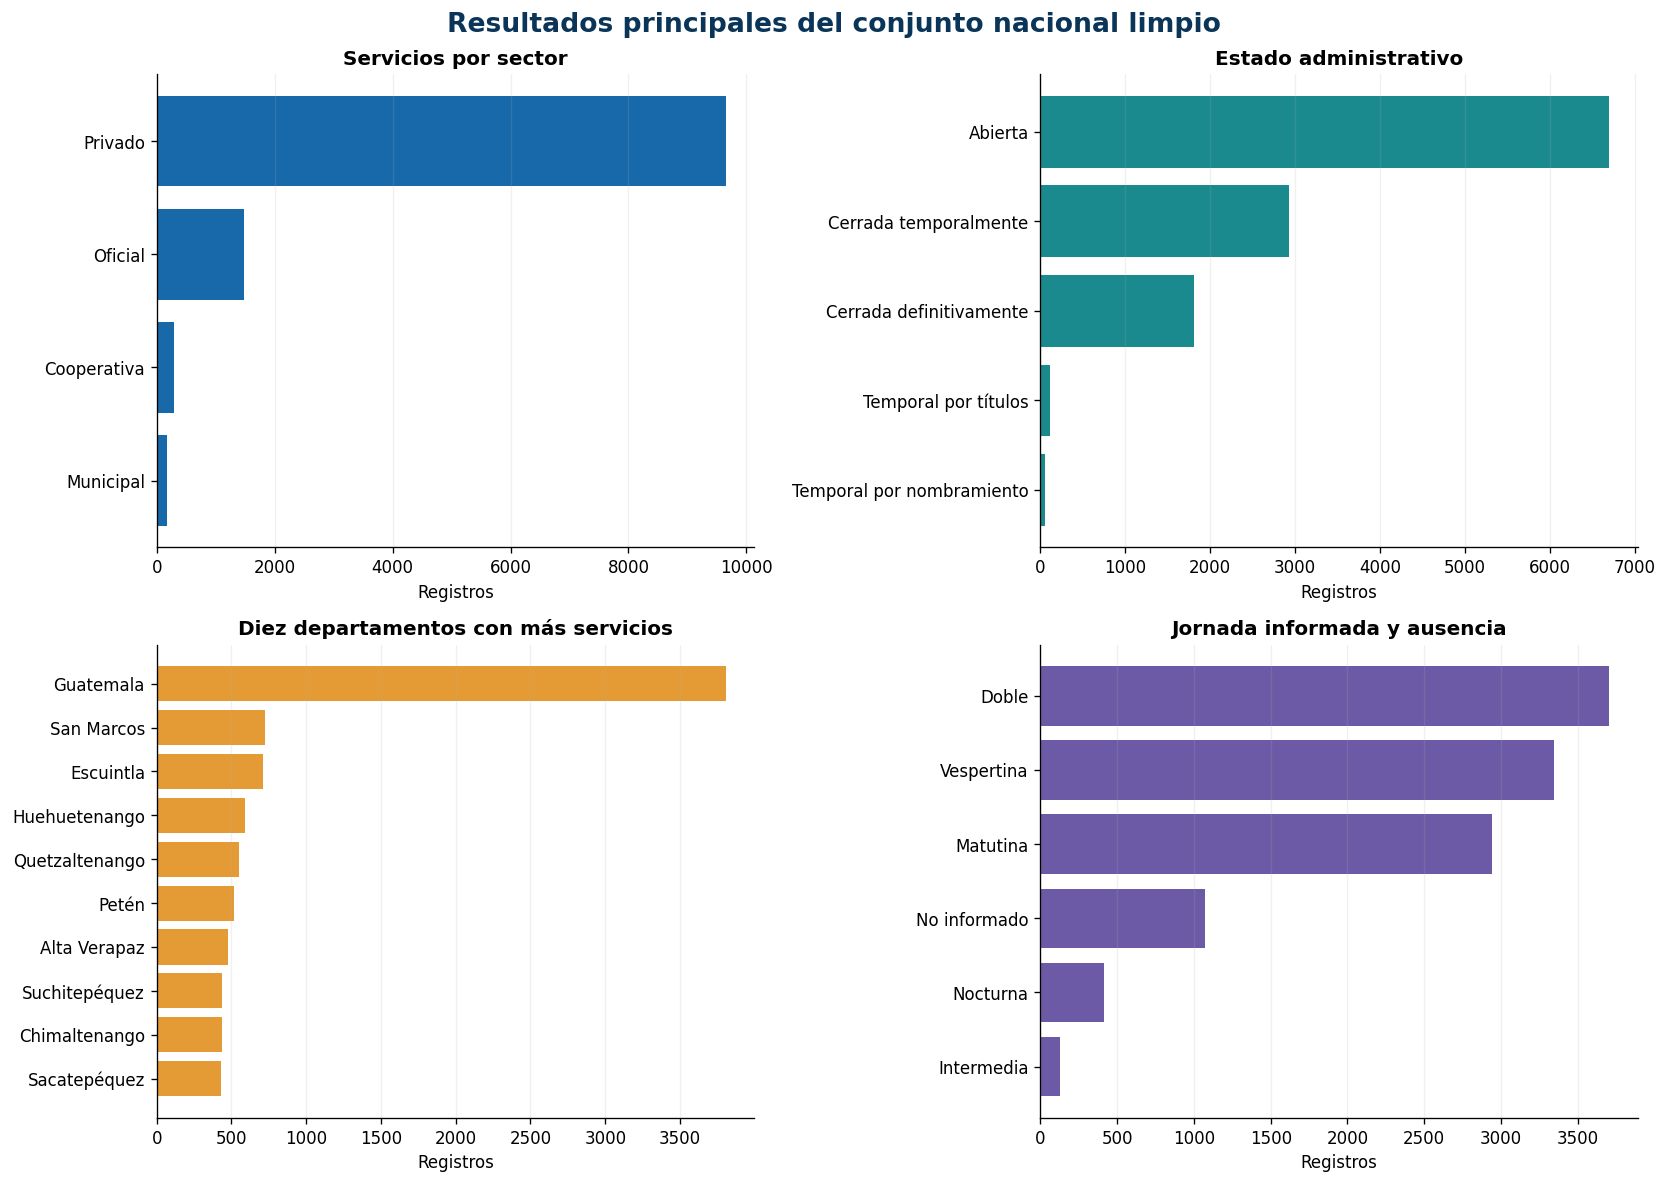

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sector_plot = dist_sector.sort_values("FILAS")
axes[0, 0].barh(sector_plot["CATEGORIA"], sector_plot["FILAS"], color=AZUL)
axes[0, 0].set_title("Servicios por sector", fontweight="bold")
axes[0, 0].set_xlabel("Registros")

status_plot = dist_status.sort_values("FILAS")
axes[0, 1].barh(status_plot["CATEGORIA"], status_plot["FILAS"], color=TURQUESA)
axes[0, 1].set_title("Estado administrativo", fontweight="bold")
axes[0, 1].set_xlabel("Registros")

dep_plot = dist_departamento.head(10).sort_values("FILAS")
axes[1, 0].barh(dep_plot["CATEGORIA"], dep_plot["FILAS"], color=NARANJA)
axes[1, 0].set_title("Diez departamentos con más servicios", fontweight="bold")
axes[1, 0].set_xlabel("Registros")

jornada_plot = dist_jornada.sort_values("FILAS")
axes[1, 1].barh(jornada_plot["CATEGORIA"], jornada_plot["FILAS"], color="#6c5aa7")
axes[1, 1].set_title("Jornada informada y ausencia", fontweight="bold")
axes[1, 1].set_xlabel("Registros")

for ax in axes.ravel():
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.18)

fig.suptitle("Resultados principales del conjunto nacional limpio", fontsize=16, fontweight="bold", color=AZUL_OSCURO)
plt.tight_layout()
fig.savefig(DIR_RESULTADOS / "resumen_distribuciones.png", dpi=180, bbox_inches="tight")
plt.show()


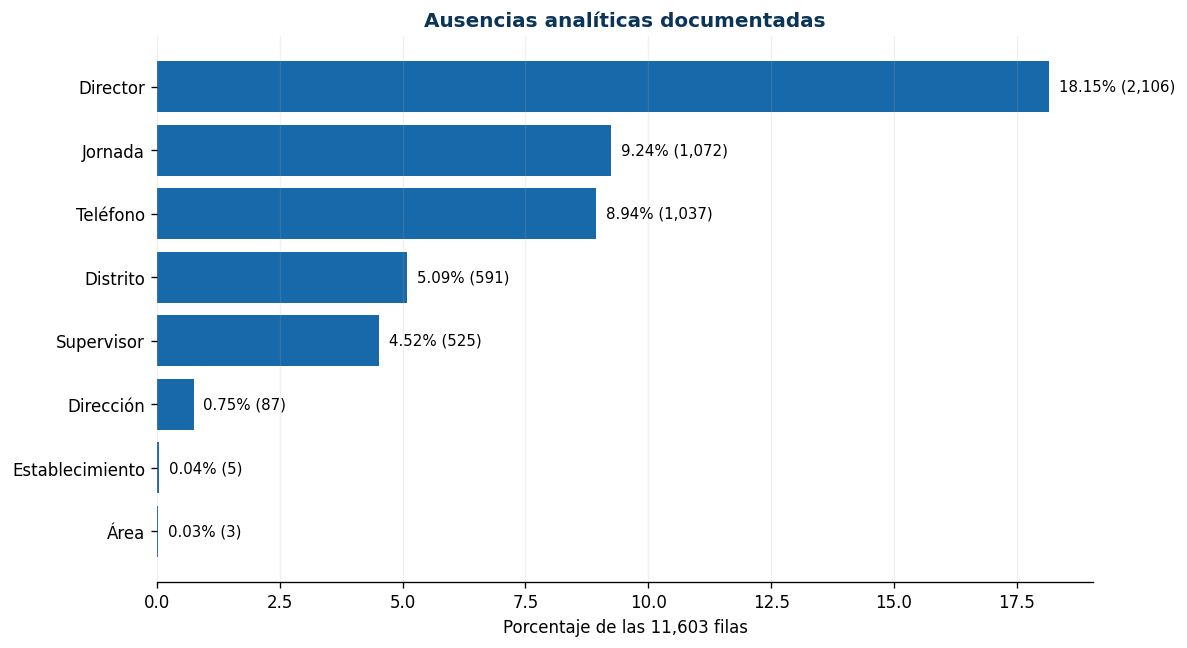

In [14]:
campos_null = [
    ("Distrito", int(limpio["DISTRITO_LIMPIO"].isna().sum())),
    ("Establecimiento", int(limpio["ESTABLECIMIENTO_LIMPIO"].isna().sum())),
    ("Dirección", int(limpio["DIRECCION_LIMPIA"].isna().sum())),
    ("Teléfono", int(limpio["TELEFONO_LIMPIO"].isna().sum())),
    ("Supervisor", int(limpio["SUPERVISOR_LIMPIO"].isna().sum())),
    ("Director", int(limpio["DIRECTOR_LIMPIO"].isna().sum())),
    ("Área", int(limpio["AREA_LIMPIA"].isna().sum())),
    ("Jornada", int(limpio["JORNADA_LIMPIA"].isna().sum())),
]
faltantes_resultado = pd.DataFrame(campos_null, columns=["VARIABLE", "NULL_ANALITICOS"])
faltantes_resultado["PORCENTAJE"] = (100 * faltantes_resultado["NULL_ANALITICOS"] / len(limpio)).round(2)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot = faltantes_resultado.sort_values("PORCENTAJE")
ax.barh(plot["VARIABLE"], plot["PORCENTAJE"], color=AZUL)
for i, (pct, n) in enumerate(zip(plot["PORCENTAJE"], plot["NULL_ANALITICOS"])):
    ax.text(pct + 0.2, i, f"{pct:.2f}% ({n:,})", va="center", fontsize=9)
ax.set_title("Ausencias analíticas documentadas", fontweight="bold", color=AZUL_OSCURO)
ax.set_xlabel("Porcentaje de las 11,603 filas")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.18)
plt.tight_layout()
fig.savefig(DIR_RESULTADOS / "faltantes_analiticos.png", dpi=180, bbox_inches="tight")
plt.show()


## 12. Interpretación de los resultados

La limpieza no pretende aumentar artificialmente la completitud. Su objetivo es **representar correctamente lo que se conoce y lo que no se conoce**, separar procedencia de agregación y producir etiquetas legibles sin destruir la evidencia original.

La tasa de conservación de registros se define como:

$$
T_{\mathrm{conservación}}=\frac{n_{\mathrm{limpio}}}{n_{\mathrm{crudo}}}\times 100=100\%.
$$

Los códigos categóricos creados son identificadores nominales. Si posteriormente se entrena un modelo, las variables nominales deberán transformarse mediante indicadores (*one-hot encoding*) y no utilizarse como si expresaran distancia.


In [15]:
abiertos = int(limpio["STATUS_LIMPIO"].eq("Abierta").sum())
privados = int(limpio["SECTOR_LIMPIO"].eq("Privado").sum())
urbanos = int(limpio["AREA_LIMPIA"].eq("Urbana").sum())
telefonos_interpretables = int(limpio["TELEFONO_PRINCIPAL"].notna().sum())

conclusiones = f'''
<div class='ds-card'>
  <h3>Conclusiones verificadas</h3>
  <ol style='line-height:1.65;color:#263746'>
    <li>Se conservaron <b>{len(limpio):,} de {len(datos):,} registros</b>; no existían duplicados exactos ni códigos repetidos; los pares parciales fueron documentados sin eliminación automática.</li>
    <li>La vista de origen mantiene <b>23 categorías</b> y la vista analítica produce <b>22 departamentos</b> sin borrar la procedencia de Ciudad Capital.</li>
    <li><b>{abiertos:,}</b> servicios ({100*abiertos/len(limpio):.2f}%) se reportan abiertos.</li>
    <li>El sector privado reúne <b>{privados:,}</b> servicios ({100*privados/len(limpio):.2f}%) y el área urbana <b>{urbanos:,}</b> ({100*urbanos/len(limpio):.2f}%).</li>
    <li>Se identificó un teléfono principal de ocho dígitos en <b>{telefonos_interpretables:,}</b> filas; los formatos no interpretables quedaron como null analítico, pero permanecen en TELEFONO_ORIGINAL.</li>
    <li>DIRECTOR conserva la mayor ausencia analítica: <b>{limpio['DIRECTOR_LIMPIO'].isna().sum():,}</b> filas.</li>
    <li>Las etiquetas originales, las columnas limpias, los catálogos, la bitácora y las pruebas automáticas permiten reproducir y auditar cada transformación.</li>
  </ol>
</div>
'''
HTMLBlock(CSS_TABLA + conclusiones)


.ds-card{border:1px solid #d9e4ee;border-radius:12px;padding:16px 18px;margin:10px 0 16px;background:#fff;box-shadow:0 4px 16px rgba(11,53,88,.06)}
.ds-card h3{color:#0b3558;margin:0 0 10px;font-size:18px}
.ds-table{border-collapse:collapse;width:100%;font-size:12px}
.ds-table th{background:#0b3558;color:white;padding:8px;text-align:left;position:sticky;top:0}
.ds-table td{padding:7px 8px;border-bottom:1px solid #e5edf3;vertical-align:top}
.ds-table tr:nth-child(even) td{background:#f7fafc}
.kpi-grid{display:grid;grid-template-columns:repeat(4,minmax(140px,1fr));gap:12px;margin:10px 0 16px}
.kpi{border-radius:12px;padding:15px;background:linear-gradient(145deg,#f2f7fb,#ffffff);border:1px solid #d7e4ee}
.kpi .label{font-size:11px;text-transform:uppercase;letter-spacing:.8px;color:#5f6b76;font-weight:700}
.kpi .value{font-size:25px;color:#0b3558;font-weight:800;margin-top:4px}
.note{padding:14px 16px;border-left:5px solid #1b8a8f;background:#eef8f7;border-radius:8px;margin:10px 0}
 

 
   Conclusiones verificadas 
   
     Se conservaron  11,603 de 11,603 registros ; no existían duplicados exactos ni códigos repetidos; los pares parciales fueron documentados sin eliminación automática. 
     La vista de origen mantiene  23 categorías  y la vista analítica produce  22 departamentos  sin borrar la procedencia de Ciudad Capital. 
      6,702  servicios (57.76%) se reportan abiertos. 
     El sector privado reúne  9,648  servicios (83.15%) y el área urbana  9,271  (79.90%). 
     Se identificó un teléfono principal de ocho dígitos en  10,566  filas; los formatos no interpretables quedaron como null analítico, pero permanecen en TELEFONO_ORIGINAL. 
     DIRECTOR conserva la mayor ausencia analítica:  2,106  filas. 
     Las etiquetas originales, las columnas limpias, los catálogos, la bitácora y las pruebas automáticas permiten reproducir y auditar cada transformación.

## 13. Limitaciones y uso responsable

- El archivo es una fotografía administrativa del portal y no demuestra que cada servicio continúe operando en la fecha de análisis.
- Los nombres de establecimientos y personas se normalizan de forma conservadora. Una corrección de identidad que no esté respaldada por la fuente requiere revisión manual u oficial.
- Los teléfonos con formatos antiguos o incompletos se conservan como texto y se marcan; no se inventan prefijos ni dígitos.
- `CIUDAD CAPITAL` es una procedencia válida de extracción. Su agrupación con Guatemala solo ocurre en `DEPARTAMENTO_ANALISIS`.
- Un nombre repetido no implica duplicación. `CODIGO` es la llave primaria del conjunto. Los pares marcados para revisión requieren contraste con el registro oficial antes de una eventual fusión.
- El catálogo territorial observado cubre 334 de los 340 municipios nacionales reportados por SEGEPLAN, porque los seis restantes no aparecen con oferta de Diversificado en este snapshot.

<div style="padding:16px 18px;background:#eef8f7;border-left:5px solid #1b8a8f;border-radius:8px;">
  <b>Resultado final:</b> el conjunto queda listo para análisis descriptivo y para integrarse a procesos posteriores, siempre que se respeten las columnas de procedencia, los indicadores de ausencia y el carácter nominal de los códigos.
</div>
